In [1]:
import pandas as pd

df = pd.read_csv("Tar_null.csv",encoding='cp949')

In [2]:
df['Target'] =df['업체분류'].map({"정상":0,"부실":1})

In [3]:
df['Target'].value_counts()

Target
0    20279
1     1086
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21365 entries, 0 to 21364
Columns: 217 entries, 업체명 to Target
dtypes: float64(199), int64(9), object(9)
memory usage: 35.4+ MB


In [5]:
pd.set_option('display.width', None)          # 줄바꿈 없이 한 줄로
pd.set_option('display.max_colwidth', None)   # 컬럼 내용도 안 잘림

list(df.columns)

['업체명',
 '업체분류',
 '업체코드',
 '종목코드',
 '종목명',
 '설립일',
 '상장일',
 '상장폐지일',
 '시장구분',
 '기업규모',
 '표준산업대분류',
 '업종구분',
 '결산년도',
 '결산월',
 '결산년월',
 'DEFAULT2',
 'F01',
 'F02',
 'F03',
 'F04',
 'F05',
 'F06',
 'F07',
 'F08',
 'F09',
 'F10',
 'F11',
 'F12',
 'F13',
 'F14',
 'F15',
 'F16',
 'F17',
 'F18',
 'F19',
 'F20',
 'F21',
 'F22',
 'F23',
 'F24',
 'F26',
 'F27',
 'F28',
 'F29',
 'F30',
 'F31',
 'F32',
 'F33',
 'F34',
 'F35',
 'F36',
 'F37',
 'F38',
 'F39',
 'F40',
 'F41',
 'F42',
 'F43',
 'F44',
 'F45',
 'F46',
 'F47',
 'F48',
 'F49',
 'F50',
 'F51',
 'FA01',
 'FA02',
 'FA03',
 'FA04',
 'FA05',
 'FA06',
 'FA07',
 'FA08',
 'FA09',
 'FA10',
 'FA11',
 'FA12',
 'FA13',
 'FA14',
 'FA15',
 'FA16',
 'FA17',
 'FA18',
 'FA19',
 'FA20',
 'FA21',
 'FA22',
 'FA23',
 'FA24',
 'FA26',
 'FA27',
 'FA28',
 'FA29',
 'FA30',
 'FA31',
 'FA32',
 'FA33',
 'FA34',
 'FA35',
 'FA36',
 'FA37',
 'FA38',
 'FA39',
 'FA40',
 'FA41',
 'FA42',
 'FA43',
 'FA44',
 'FA45',
 'FA46',
 'FA47',
 'FA48',
 'FA49',
 'FA50',
 'FA51',
 'F

In [6]:
# 제거할 변수들

cols_to_drop = [
    'FB49','FA49','FA51','FB26','FA26','FA50','FA30','FA31','F49','FC49',
    'FB51','FB50','FB30','FB31','F26','FC26','F51','FC51','F50','FC50',
    'F30','F31','FC30','FC31','FA34','F34','FB34','FC34','FA41','FA32',
    'FA28','F41','FB41','FC41','F32','FB32','FC32','FA46','FA06','FA22',
    'F46','FB46','FC46','업체명','업체분류','업체코드','종목코드','종목명',
    '설립일','상장일','상장폐지일','시장구분','기업규모',
    '표준산업대분류','업종구분','결산월','결산년월','DEFAULT2'
]

# 데이터에서 제거
data = df.drop(columns=cols_to_drop, errors='ignore')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21365 entries, 0 to 21364
Columns: 159 entries, 결산년도 to Target
dtypes: float64(155), int64(4)
memory usage: 25.9 MB


In [8]:
data['Target'].value_counts()

Target
0    20279
1     1086
Name: count, dtype: int64

In [9]:
train = data[data['결산년도']<=2023].drop(columns=['결산년도'])
test = data[data['결산년도']==2024].drop(columns=['결산년도'])

In [10]:
print(train['Target'].value_counts())
print(test['Target'].value_counts())

Target
0    17974
1     1054
Name: count, dtype: int64
Target
0    2305
1      32
Name: count, dtype: int64


X_train shape: (12177, 157)
X_valid shape: (3045, 157)
X_test shape : (3806, 157)
Train positive ratio: 0.05535025047220169

Logistic | RandomizedSearchCV
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Params:
{'smote__sampling_strategy': 0.15, 'model__C': 5}
Best CV avg_precision: 0.35905322318054217

----------------------------------------------------------------------------------------------------
[Logistic] FINAL
----------------------------------------------------------------------------------------------------
Best Params:
{'smote__sampling_strategy': 0.15, 'model__C': 5}

Best CV avg_precision: 0.359053
Validation Best Threshold: 0.22

[Test Set Performance]
Accuracy          : 0.893064
Recall            : 0.620853
Specificity       : 0.909040
Precision         : 0.286026
F1-score          : 0.391629
F2-score          : 0.503072
ROC-AUC           : 0.869565
Average Precision : 0.414830

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    3268     327
Actua

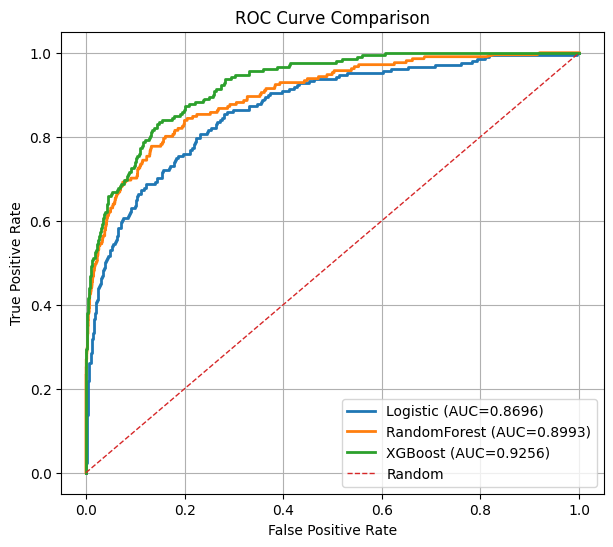

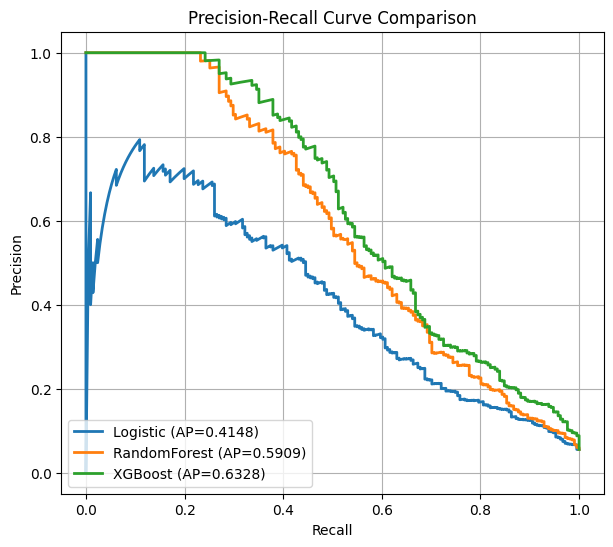

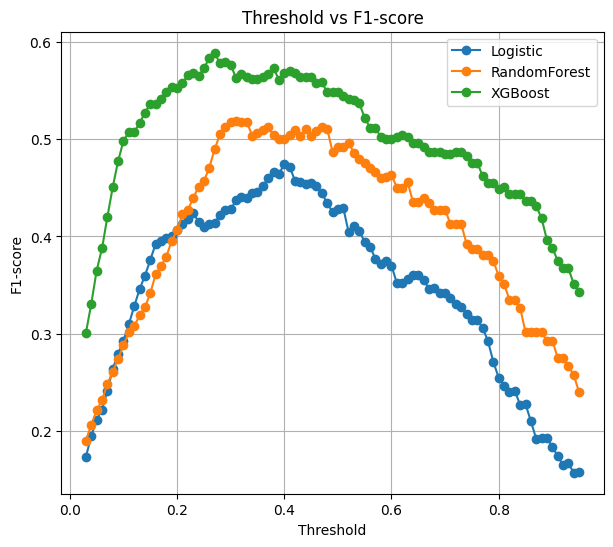

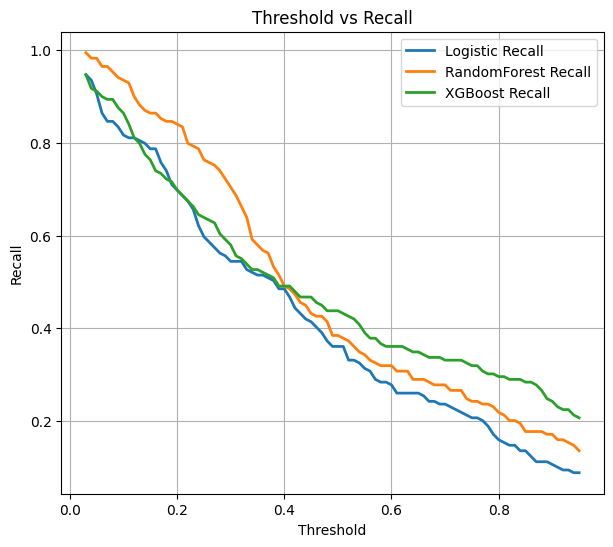


Logistic TOP VARIABLE IMPORTANCE
   feature  coefficient  abs_coefficient    direction
0     FC36    -9.682034         9.682034  negative(-)
1      F36    -9.112229         9.112229  negative(-)
2     FB36    -6.569110         6.569110  negative(-)
3      F27    -5.940313         5.940313  negative(-)
4     FC15    -5.558652         5.558652  negative(-)
5      F15     4.377730         4.377730  positive(+)
6      F28    -3.840833         3.840833  negative(-)
7     FC07     3.664431         3.664431  positive(+)
8      F07    -3.549380         3.549380  negative(-)
9     FB03     3.353298         3.353298  positive(+)
10    FB40    -3.236141         3.236141  negative(-)
11     F23    -3.073210         3.073210  negative(-)
12    FB48    -2.904162         2.904162  negative(-)
13     F17     2.831525         2.831525  positive(+)
14    FB27     2.822121         2.822121  positive(+)
15     F20     2.803060         2.803060  positive(+)
16    FC18    -2.785213         2.785213  negati

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")


# =========================================================
# 1. Threshold 선택 함수
# =========================================================
def find_best_threshold(y_true, y_proba, min_precision=0.30):
    thresholds = np.arange(0.03, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": f2 + 0.03 * rec
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


# =========================================================
# 2. 평가 함수
# =========================================================
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_test, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


# =========================================================
# 3. 변수 중요도 함수
# =========================================================
def get_feature_importance(model, model_name, feature_names, top_n=20):
    if model_name in ["RandomForest", "XGBoost"]:
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.named_steps["model"].feature_importances_
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    elif model_name == "Logistic":
        coef = model.named_steps["model"].coef_[0]
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef),
            "direction": np.where(coef >= 0, "positive(+)", "negative(-)")
        }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    return None


# =========================================================
# 4. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape :", X_test.shape)
print("Train positive ratio:", y_train.mean())


# =========================================================
# 5. CV, Scoring
# =========================================================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


# =========================================================
# 6. 모델 정의
# =========================================================
smote_ratio_grid = [0.10, 0.15, 0.20, 0.25]

model_configs = {
    "Logistic": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                penalty="l2",
                random_state=42
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__C": [0.1, 0.5, 1, 3, 5]
        },
        "n_iter": 8
    },

    "RandomForest": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=None
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 6, 10, 15],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        },
        "n_iter": 15
    },

    "XGBoost": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 300, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__min_child_weight": [3, 5, 7],
            "model__subsample": [0.8, 0.9],
            "model__colsample_bytree": [0.7, 0.8],
            "model__reg_lambda": [1, 5, 10],
            "model__reg_alpha": [0, 0.1, 1]
        },
        "n_iter": 15
    }
}


# =========================================================
# 7. 모델 학습 + Threshold Tuning + Test 평가
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}
importance_tables = {}

for model_name, cfg in model_configs.items():
    print("\n" + "=" * 100)
    print(f"{model_name} | RandomizedSearchCV")
    print("=" * 100)

    search = RandomizedSearchCV(
        estimator=cfg["pipeline"],
        param_distributions=cfg["param_dist"],
        n_iter=cfg["n_iter"],
        scoring=scoring,
        refit="avg_precision",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    print("\nBest Params:")
    print(search.best_params_)
    print("Best CV avg_precision:", search.best_score_)

    # Validation set에서 threshold 선택
    valid_proba = best_model.predict_proba(X_valid)[:, 1]
    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        min_precision=0.30
    )

    threshold_tables[model_name] = threshold_df
    best_threshold = float(best_threshold_row["threshold"])

    # Test set 평가
    eval_result = evaluate_model(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        threshold=best_threshold
    )

    # ROC / PR Curve 저장
    fpr, tpr, _ = roc_curve(y_test, eval_result["y_proba"])
    roc_data[model_name] = (fpr, tpr, eval_result["ROC_AUC"])

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, eval_result["y_proba"])
    pr_data[model_name] = (pr_recall, pr_precision, eval_result["Avg_Precision"])

    # 변수 중요도
    importance_df = get_feature_importance(
        model=best_model,
        model_name=model_name,
        feature_names=X_train.columns.tolist(),
        top_n=20
    )
    importance_tables[model_name] = importance_df

    print("\n" + "-" * 100)
    print(f"[{model_name}] FINAL")
    print("-" * 100)
    print("Best Params:")
    print(search.best_params_)
    print(f"\nBest CV avg_precision: {search.best_score_:.6f}")
    print(f"Validation Best Threshold: {best_threshold:.2f}")

    print("\n[Test Set Performance]")
    print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
    print(f"Recall            : {eval_result['Recall']:.6f}")
    print(f"Specificity       : {eval_result['Specificity']:.6f}")
    print(f"Precision         : {eval_result['Precision']:.6f}")
    print(f"F1-score          : {eval_result['F1_score']:.6f}")
    print(f"F2-score          : {eval_result['F2_score']:.6f}")
    print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
    print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        eval_result["Confusion_Matrix"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(eval_result["Classification_Report"])

    print("\nTop Variable Importance:")
    print(importance_df)

    results.append({
        "Model": model_name,
        "Num_Features": X_train.shape[1],
        "Best_CV_avg_precision": search.best_score_,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": eval_result["Accuracy"],
        "Recall": eval_result["Recall"],
        "Specificity": eval_result["Specificity"],
        "Precision": eval_result["Precision"],
        "F1_score": eval_result["F1_score"],
        "F2_score": eval_result["F2_score"],
        "ROC_AUC": eval_result["ROC_AUC"],
        "Avg_Precision": eval_result["Avg_Precision"],
        "Best_Params": search.best_params_
    })


# =========================================================
# 8. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F1_score", "Recall", "Avg_Precision", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(results_df[[
    "Model",
    "Num_Features",
    "Best_CV_avg_precision",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Specificity",
    "Precision",
    "F1_score",
    "F2_score",
    "ROC_AUC",
    "Avg_Precision"
]])


# =========================================================
# 9. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 10. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_score:.4f})"
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 11. Threshold vs F1 / Recall
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f1"], marker="o", label=name)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["recall"], linewidth=2, label=f"{name} Recall")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 12. 변수 중요도 재출력
# =========================================================
for name, imp_df in importance_tables.items():
    print("\n" + "=" * 100)
    print(f"{name} TOP VARIABLE IMPORTANCE")
    print("=" * 100)
    print(imp_df)


# =========================================================
# 13. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print(f"최종 추천 모델: {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])


# =========================================================
# 14. SHAP 분석
# =========================================================
# SHAP은 최종 추천 모델이 XGBoost 또는 RandomForest일 때만 권장
# Logistic이 최종 추천 모델이면 계수 해석을 사용하면 됨.

try:
    import shap

    shap_model_name = best_model_name

    if shap_model_name in ["XGBoost", "RandomForest"]:
        print("\n" + "=" * 100)
        print(f"SHAP Analysis for {shap_model_name}")
        print("=" * 100)

        final_model = best_models[shap_model_name]
        tree_model = final_model.named_steps["model"]

        # SHAP 속도 조절용 샘플링
        sample_size = min(500, len(X_valid))
        X_shap = X_valid.sample(sample_size, random_state=42)

        explainer = shap.TreeExplainer(tree_model)
        shap_values = explainer.shap_values(X_shap)

        # XGBoost는 보통 shap_values가 array
        # RandomForest는 경우에 따라 list로 나올 수 있음
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar")
        shap.summary_plot(shap_values_to_plot, X_shap)

    else:
        print("\n최종 추천 모델이 Logistic이므로 SHAP 대신 회귀계수 기반 해석을 권장합니다.")
        print(importance_tables["Logistic"])

except ImportError:
    print("\nshap 패키지가 설치되어 있지 않습니다.")
    print("설치 후 다시 실행하세요: pip install shap")

In [13]:
pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   --------------------------------------- 555.9/555.9 kB 10.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ------- -------------------------------- 7.6/38.1 MB 36.1 MB/s eta 0:00:01
   --------------- ------------------------ 14.7/38.1 MB 35.5 MB/s eta 0:00:01
   -------------------------------------- - 36.4/38.1 MB 59.3 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 60.6 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 60.6 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 60.6 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 28.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 47.2 MB/s eta 0:00:00

   ----- ---------------------------------- 1/7 [tqdm]
   ----- ----------------


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


X_train shape: (12177, 157)
X_valid shape: (3045, 157)
X_test shape : (3806, 157)
Train positive ratio: 0.05535025047220169
Valid positive ratio: 0.0555008210180624
Test positive ratio : 0.055438780872306886

Logistic | RandomizedSearchCV
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Params:
{'smote__sampling_strategy': 0.15, 'model__C': 30}
Best CV avg_precision: 0.38877874355996206

----------------------------------------------------------------------------------------------------
[Logistic] FINAL
----------------------------------------------------------------------------------------------------
Best Params:
{'smote__sampling_strategy': 0.15, 'model__C': 30}

Best CV avg_precision: 0.388779
Validation Best Threshold: 0.39

[Test Set Performance]
Accuracy          : 0.940620
Recall            : 0.483412
Specificity       : 0.967455
Precision         : 0.465753
F1-score          : 0.474419
F2-score          : 0.479774
ROC-AUC           : 0.873347
Average Precisi

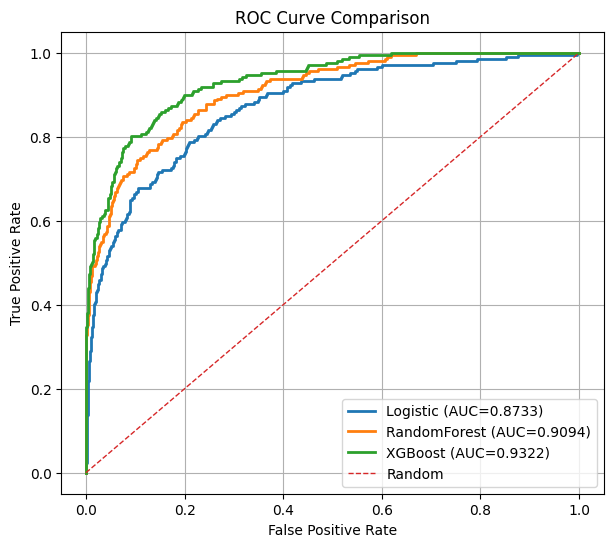

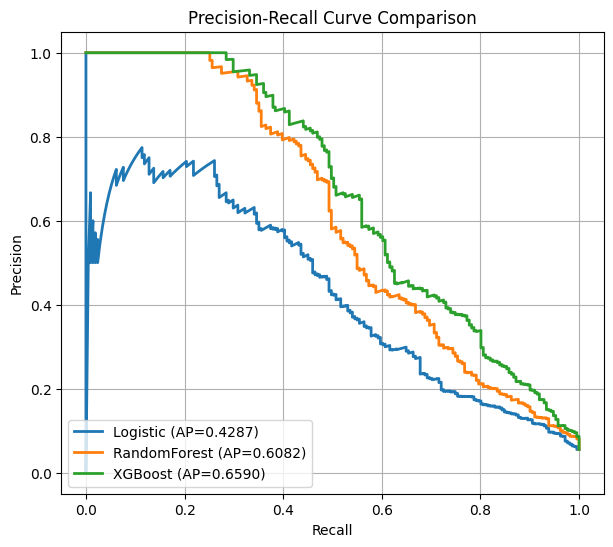

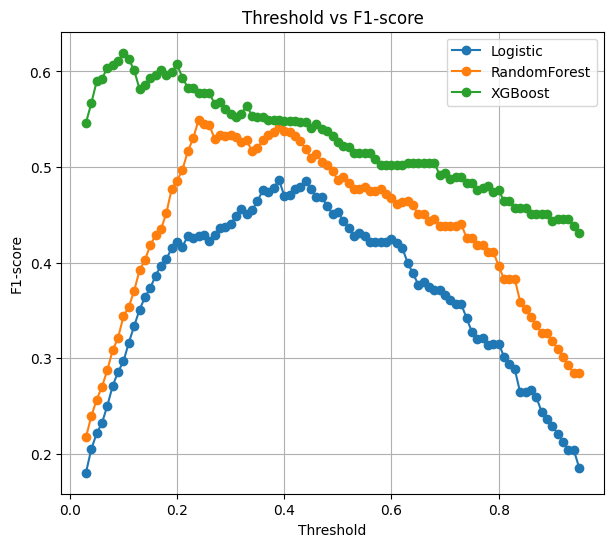

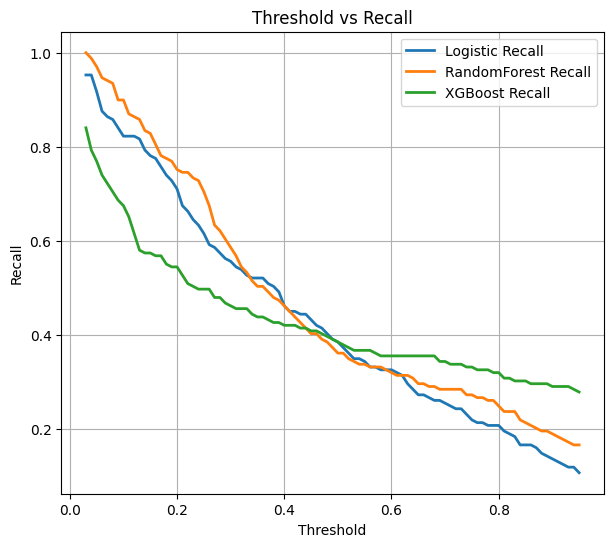

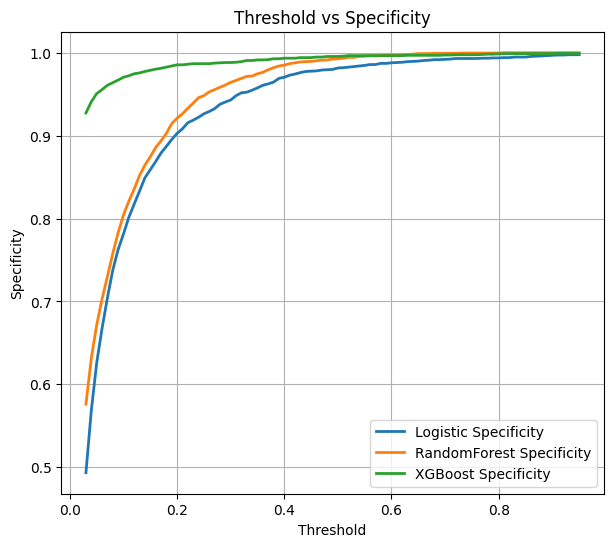


Logistic TOP VARIABLE IMPORTANCE
   feature  coefficient  abs_coefficient    direction
0     FC36   -17.471577        17.471577  negative(-)
1      F27   -16.426215        16.426215  negative(-)
2      F36   -16.156349        16.156349  negative(-)
3      F15    15.609958        15.609958  positive(+)
4     FC15   -12.745512        12.745512  negative(-)
5     FC27    10.180168        10.180168  positive(+)
6     FB09    -8.807449         8.807449  negative(-)
7      F09    -8.425198         8.425198  negative(-)
8     FC22    -7.895261         7.895261  negative(-)
9     FB28    -7.862129         7.862129  negative(-)
10    FC28     7.855823         7.855823  positive(+)
11    FC04     7.250087         7.250087  positive(+)
12     F04    -7.181798         7.181798  negative(-)
13     F23    -7.139714         7.139714  negative(-)
14    FC08     6.988655         6.988655  positive(+)
15     F17     6.856012         6.856012  positive(+)
16    FB43    -6.550408         6.550408  negati

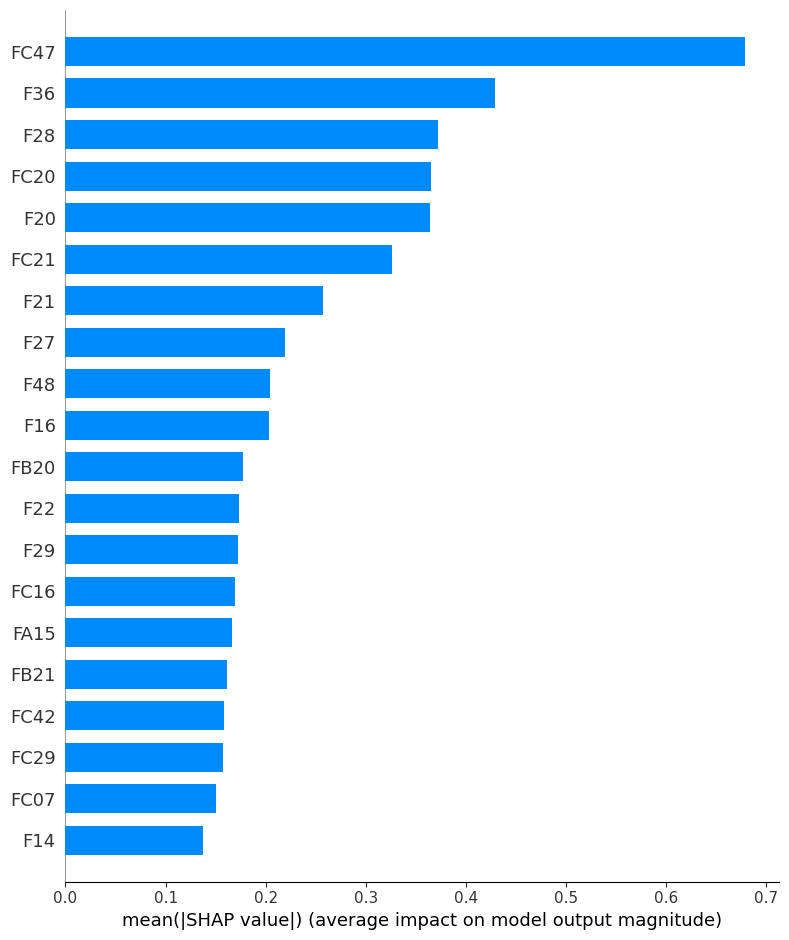

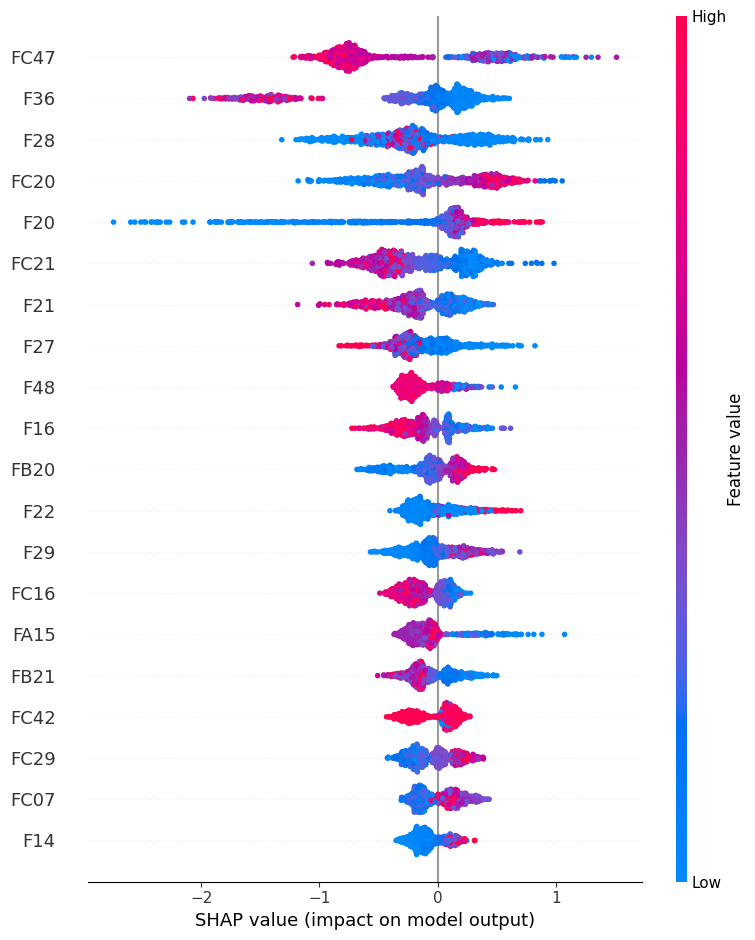

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
    make_scorer
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")


# =========================================================
# 1. Threshold 선택 함수
# =========================================================
def find_best_threshold(y_true, y_proba, min_precision=0.30):
    thresholds = np.arange(0.03, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": f1 + 0.02 * rec + 0.01 * specificity
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f1", "recall", "specificity", "precision"],
            ascending=[False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f1", "recall", "specificity", "precision"],
            ascending=[False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


# =========================================================
# 2. 평가 함수
# =========================================================
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_test, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


# =========================================================
# 3. Specificity scorer
# =========================================================
def specificity_score_func(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) != 0 else 0

specificity_scorer = make_scorer(specificity_score_func)


# =========================================================
# 4. 변수 중요도 함수
# =========================================================
def get_feature_importance(model, model_name, feature_names, top_n=30):
    if model_name in ["RandomForest", "XGBoost"]:
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.named_steps["model"].feature_importances_
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    elif model_name == "Logistic":
        coef = model.named_steps["model"].coef_[0]
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef),
            "direction": np.where(coef >= 0, "positive(+)", "negative(-)")
        }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    return None


# =========================================================
# 5. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape :", X_test.shape)
print("Train positive ratio:", y_train.mean())
print("Valid positive ratio:", y_valid.mean())
print("Test positive ratio :", y_test.mean())


# =========================================================
# 6. CV, Scoring
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "specificity": specificity_scorer
}


# =========================================================
# 7. 모델 정의: 3시간용 탐색량
# =========================================================
smote_ratio_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

model_configs = {
    "Logistic": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=7000,
                solver="lbfgs",
                penalty="l2",
                random_state=42
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__C": [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1, 3, 5, 10, 30, 50]
        },
        "n_iter": 40
    },

    "RandomForest": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [300, 500, 700, 900, 1100, 1300, 1500],
            "model__max_depth": [None, 4, 6, 8, 10, 12, 15, 20, 25],
            "model__min_samples_split": [2, 5, 10, 15, 20, 30],
            "model__min_samples_leaf": [1, 2, 3, 4, 6, 8, 10],
            "model__max_features": ["sqrt", "log2", 0.2, 0.3, 0.5, 0.7],
            "model__criterion": ["gini", "entropy"],
            "model__bootstrap": [True]
        },
        "n_iter": 120
    },

    "XGBoost": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [300, 500, 700, 900, 1100, 1300],
            "model__learning_rate": [0.003, 0.005, 0.01, 0.03, 0.05, 0.07, 0.1],
            "model__max_depth": [2, 3, 4, 5, 6, 7],
            "model__min_child_weight": [1, 2, 3, 5, 7, 10, 15],
            "model__subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "model__gamma": [0, 0.01, 0.05, 0.1, 0.3, 0.5, 1, 2],
            "model__reg_alpha": [0, 0.001, 0.01, 0.1, 1, 3, 5],
            "model__reg_lambda": [0.5, 1, 3, 5, 10, 20, 30, 50]
        },
        "n_iter": 180
    }
}


# =========================================================
# 8. 모델 학습 + Threshold Tuning + Test 평가
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}
importance_tables = {}

for model_name, cfg in model_configs.items():
    print("\n" + "=" * 100)
    print(f"{model_name} | RandomizedSearchCV")
    print("=" * 100)

    search = RandomizedSearchCV(
        estimator=cfg["pipeline"],
        param_distributions=cfg["param_dist"],
        n_iter=cfg["n_iter"],
        scoring=scoring,
        refit="avg_precision",
        cv=cv,
        verbose=2,
        random_state=42,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    print("\nBest Params:")
    print(search.best_params_)
    print("Best CV avg_precision:", search.best_score_)

    valid_proba = best_model.predict_proba(X_valid)[:, 1]

    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        min_precision=0.30
    )

    threshold_tables[model_name] = threshold_df
    best_threshold = float(best_threshold_row["threshold"])

    eval_result = evaluate_model(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        threshold=best_threshold
    )

    fpr, tpr, _ = roc_curve(y_test, eval_result["y_proba"])
    roc_data[model_name] = (fpr, tpr, eval_result["ROC_AUC"])

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, eval_result["y_proba"])
    pr_data[model_name] = (pr_recall, pr_precision, eval_result["Avg_Precision"])

    importance_df = get_feature_importance(
        model=best_model,
        model_name=model_name,
        feature_names=X_train.columns.tolist(),
        top_n=30
    )
    importance_tables[model_name] = importance_df

    print("\n" + "-" * 100)
    print(f"[{model_name}] FINAL")
    print("-" * 100)
    print("Best Params:")
    print(search.best_params_)
    print(f"\nBest CV avg_precision: {search.best_score_:.6f}")
    print(f"Validation Best Threshold: {best_threshold:.2f}")

    print("\n[Test Set Performance]")
    print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
    print(f"Recall            : {eval_result['Recall']:.6f}")
    print(f"Specificity       : {eval_result['Specificity']:.6f}")
    print(f"Precision         : {eval_result['Precision']:.6f}")
    print(f"F1-score          : {eval_result['F1_score']:.6f}")
    print(f"F2-score          : {eval_result['F2_score']:.6f}")
    print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
    print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        eval_result["Confusion_Matrix"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(eval_result["Classification_Report"])

    print("\nTop Variable Importance:")
    print(importance_df)

    results.append({
        "Model": model_name,
        "Num_Features": X_train.shape[1],
        "Best_CV_avg_precision": search.best_score_,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": eval_result["Accuracy"],
        "Recall": eval_result["Recall"],
        "Specificity": eval_result["Specificity"],
        "Precision": eval_result["Precision"],
        "F1_score": eval_result["F1_score"],
        "F2_score": eval_result["F2_score"],
        "ROC_AUC": eval_result["ROC_AUC"],
        "Avg_Precision": eval_result["Avg_Precision"],
        "Best_Params": search.best_params_
    })


# =========================================================
# 9. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F1_score", "Recall", "Specificity", "Avg_Precision", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(results_df[[
    "Model",
    "Num_Features",
    "Best_CV_avg_precision",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Specificity",
    "Precision",
    "F1_score",
    "F2_score",
    "ROC_AUC",
    "Avg_Precision"
]])


# =========================================================
# 10. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 11. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_score:.4f})"
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 12. Threshold vs F1 / Recall / Specificity
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f1"], marker="o", label=name)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["recall"], linewidth=2, label=f"{name} Recall")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["specificity"], linewidth=2, label=f"{name} Specificity")
plt.xlabel("Threshold")
plt.ylabel("Specificity")
plt.title("Threshold vs Specificity")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 13. 변수 중요도 재출력
# =========================================================
for name, imp_df in importance_tables.items():
    print("\n" + "=" * 100)
    print(f"{name} TOP VARIABLE IMPORTANCE")
    print("=" * 100)
    print(imp_df)


# =========================================================
# 14. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print(f"최종 추천 모델: {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])


# =========================================================
# 15. SHAP 분석
# =========================================================
try:
    import shap

    shap_model_name = best_model_name

    if shap_model_name in ["XGBoost", "RandomForest"]:
        print("\n" + "=" * 100)
        print(f"SHAP Analysis for {shap_model_name}")
        print("=" * 100)

        final_model = best_models[shap_model_name]
        tree_model = final_model.named_steps["model"]

        sample_size = min(1000, len(X_valid))
        X_shap = X_valid.sample(sample_size, random_state=42)

        explainer = shap.TreeExplainer(tree_model)
        shap_values = explainer.shap_values(X_shap)

        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar")
        shap.summary_plot(shap_values_to_plot, X_shap)

    else:
        print("\n최종 추천 모델이 Logistic이므로 SHAP 대신 회귀계수 기반 해석을 권장합니다.")
        print(importance_tables["Logistic"])

except ImportError:
    print("\nshap 패키지가 설치되어 있지 않습니다.")
    print("설치 후 다시 실행하세요: pip install shap")

X_train shape: (12177, 157)
X_valid shape: (3045, 157)
X_test shape : (3806, 157)
Train positive ratio: 0.05535025047220169

Logistic | RandomizedSearchCV
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Params:
{'smote__sampling_strategy': 0.15, 'model__C': 5}
Best CV avg_precision: 0.35905322318054217

----------------------------------------------------------------------------------------------------
[Logistic] FINAL
----------------------------------------------------------------------------------------------------
Best Params:
{'smote__sampling_strategy': 0.15, 'model__C': 5}

Best CV avg_precision: 0.359053
Validation Best Threshold: 0.22

[Test Set Performance]
Accuracy          : 0.893064
Recall            : 0.620853
Specificity       : 0.909040
Precision         : 0.286026
F1-score          : 0.391629
F2-score          : 0.503072
ROC-AUC           : 0.869565
Average Precision : 0.414830

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    3268     327
Actua

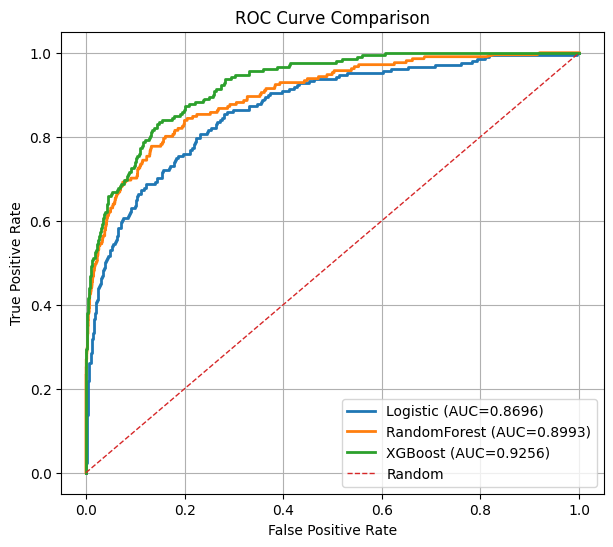

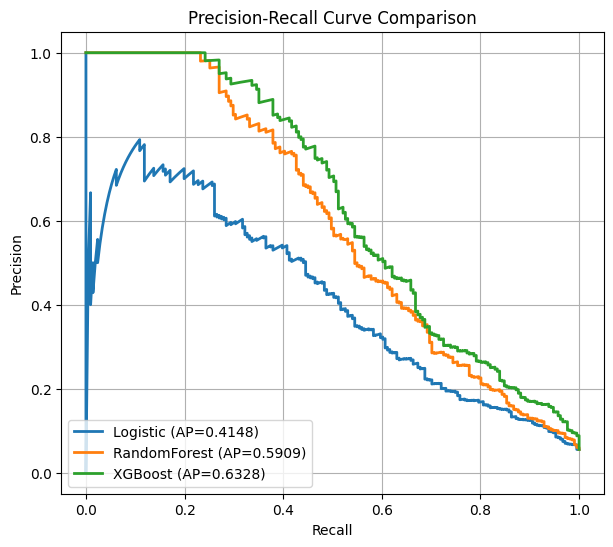

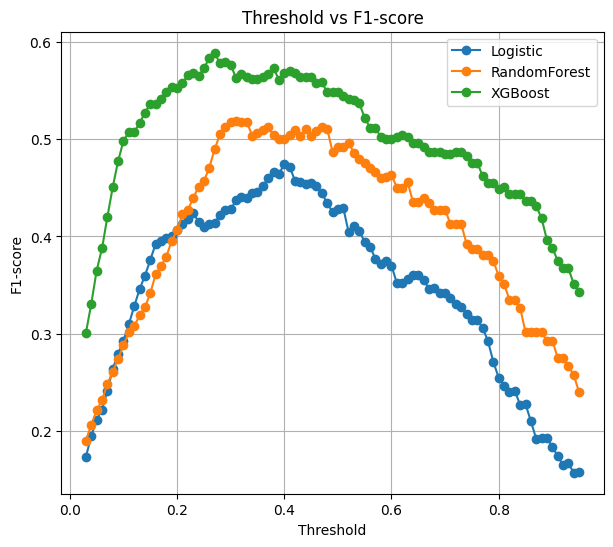

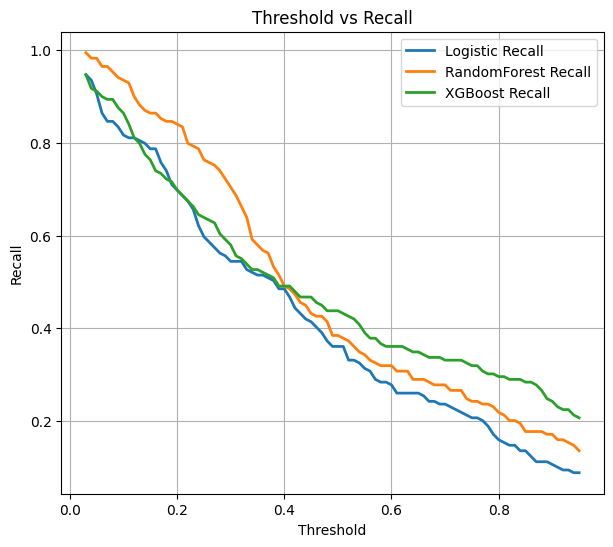


Logistic TOP VARIABLE IMPORTANCE
   feature  coefficient  abs_coefficient    direction
0     FC36    -9.682034         9.682034  negative(-)
1      F36    -9.112229         9.112229  negative(-)
2     FB36    -6.569110         6.569110  negative(-)
3      F27    -5.940313         5.940313  negative(-)
4     FC15    -5.558652         5.558652  negative(-)
5      F15     4.377730         4.377730  positive(+)
6      F28    -3.840833         3.840833  negative(-)
7     FC07     3.664431         3.664431  positive(+)
8      F07    -3.549380         3.549380  negative(-)
9     FB03     3.353298         3.353298  positive(+)
10    FB40    -3.236141         3.236141  negative(-)
11     F23    -3.073210         3.073210  negative(-)
12    FB48    -2.904162         2.904162  negative(-)
13     F17     2.831525         2.831525  positive(+)
14    FB27     2.822121         2.822121  positive(+)
15     F20     2.803060         2.803060  positive(+)
16    FC18    -2.785213         2.785213  negati

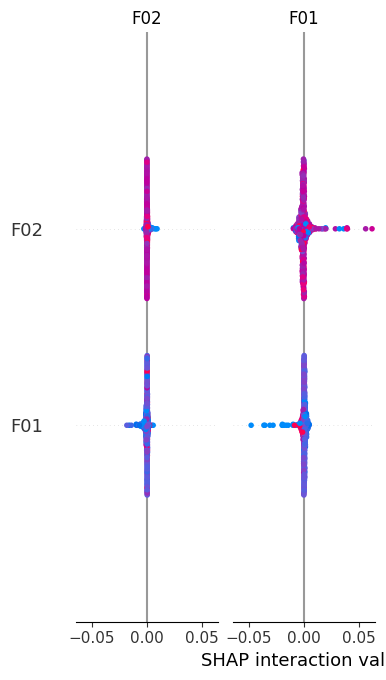

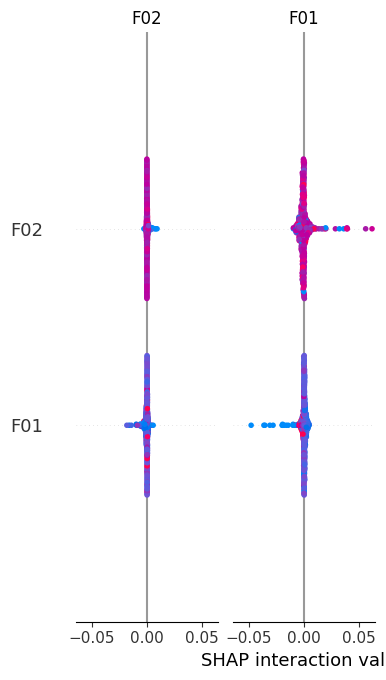

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")


# =========================================================
# 1. Threshold 선택 함수
# =========================================================
def find_best_threshold(y_true, y_proba, min_precision=0.30):
    thresholds = np.arange(0.03, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": f2 + 0.03 * rec
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "threshold"],
            ascending=[False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


# =========================================================
# 2. 평가 함수
# =========================================================
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    f2 = 0 if (4 * prec + rec) == 0 else (5 * prec * rec) / (4 * prec + rec)

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_test, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


# =========================================================
# 3. 변수 중요도 함수
# =========================================================
def get_feature_importance(model, model_name, feature_names, top_n=20):
    if model_name in ["RandomForest", "XGBoost"]:
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.named_steps["model"].feature_importances_
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    elif model_name == "Logistic":
        coef = model.named_steps["model"].coef_[0]
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef),
            "direction": np.where(coef >= 0, "positive(+)", "negative(-)")
        }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
        return importance_df.head(top_n)

    return None


# =========================================================
# 4. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape :", X_test.shape)
print("Train positive ratio:", y_train.mean())


# =========================================================
# 5. CV, Scoring
# =========================================================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


# =========================================================
# 6. 모델 정의
# =========================================================
smote_ratio_grid = [0.10, 0.15, 0.20, 0.25]

model_configs = {
    "Logistic": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                penalty="l2",
                random_state=42
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__C": [0.1, 0.5, 1, 3, 5]
        },
        "n_iter": 8
    },

    "RandomForest": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=None
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 6, 10, 15],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        },
        "n_iter": 15
    },

    "XGBoost": {
        "pipeline": ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            ))
        ]),
        "param_dist": {
            "smote__sampling_strategy": smote_ratio_grid,
            "model__n_estimators": [200, 300, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__min_child_weight": [3, 5, 7],
            "model__subsample": [0.8, 0.9],
            "model__colsample_bytree": [0.7, 0.8],
            "model__reg_lambda": [1, 5, 10],
            "model__reg_alpha": [0, 0.1, 1]
        },
        "n_iter": 15
    }
}


# =========================================================
# 7. 모델 학습 + Threshold Tuning + Test 평가
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}
importance_tables = {}

for model_name, cfg in model_configs.items():
    print("\n" + "=" * 100)
    print(f"{model_name} | RandomizedSearchCV")
    print("=" * 100)

    search = RandomizedSearchCV(
        estimator=cfg["pipeline"],
        param_distributions=cfg["param_dist"],
        n_iter=cfg["n_iter"],
        scoring=scoring,
        refit="avg_precision",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model

    print("\nBest Params:")
    print(search.best_params_)
    print("Best CV avg_precision:", search.best_score_)

    # Validation set에서 threshold 선택
    valid_proba = best_model.predict_proba(X_valid)[:, 1]
    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        min_precision=0.30
    )

    threshold_tables[model_name] = threshold_df
    best_threshold = float(best_threshold_row["threshold"])

    # Test set 평가
    eval_result = evaluate_model(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        threshold=best_threshold
    )

    # ROC / PR Curve 저장
    fpr, tpr, _ = roc_curve(y_test, eval_result["y_proba"])
    roc_data[model_name] = (fpr, tpr, eval_result["ROC_AUC"])

    pr_precision, pr_recall, _ = precision_recall_curve(y_test, eval_result["y_proba"])
    pr_data[model_name] = (pr_recall, pr_precision, eval_result["Avg_Precision"])

    # 변수 중요도
    importance_df = get_feature_importance(
        model=best_model,
        model_name=model_name,
        feature_names=X_train.columns.tolist(),
        top_n=20
    )
    importance_tables[model_name] = importance_df

    print("\n" + "-" * 100)
    print(f"[{model_name}] FINAL")
    print("-" * 100)
    print("Best Params:")
    print(search.best_params_)
    print(f"\nBest CV avg_precision: {search.best_score_:.6f}")
    print(f"Validation Best Threshold: {best_threshold:.2f}")

    print("\n[Test Set Performance]")
    print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
    print(f"Recall            : {eval_result['Recall']:.6f}")
    print(f"Specificity       : {eval_result['Specificity']:.6f}")
    print(f"Precision         : {eval_result['Precision']:.6f}")
    print(f"F1-score          : {eval_result['F1_score']:.6f}")
    print(f"F2-score          : {eval_result['F2_score']:.6f}")
    print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
    print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        eval_result["Confusion_Matrix"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(eval_result["Classification_Report"])

    print("\nTop Variable Importance:")
    print(importance_df)

    results.append({
        "Model": model_name,
        "Num_Features": X_train.shape[1],
        "Best_CV_avg_precision": search.best_score_,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": eval_result["Accuracy"],
        "Recall": eval_result["Recall"],
        "Specificity": eval_result["Specificity"],
        "Precision": eval_result["Precision"],
        "F1_score": eval_result["F1_score"],
        "F2_score": eval_result["F2_score"],
        "ROC_AUC": eval_result["ROC_AUC"],
        "Avg_Precision": eval_result["Avg_Precision"],
        "Best_Params": search.best_params_
    })


# =========================================================
# 8. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F1_score", "Recall", "Avg_Precision", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(results_df[[
    "Model",
    "Num_Features",
    "Best_CV_avg_precision",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Specificity",
    "Precision",
    "F1_score",
    "F2_score",
    "ROC_AUC",
    "Avg_Precision"
]])


# =========================================================
# 9. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 10. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))
for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_score:.4f})"
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 11. Threshold vs F1 / Recall
# =========================================================
plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f1"], marker="o", label=name)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold vs F1-score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["recall"], linewidth=2, label=f"{name} Recall")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 12. 변수 중요도 재출력
# =========================================================
for name, imp_df in importance_tables.items():
    print("\n" + "=" * 100)
    print(f"{name} TOP VARIABLE IMPORTANCE")
    print("=" * 100)
    print(imp_df)


# =========================================================
# 13. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print(f"최종 추천 모델: {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])


# =========================================================
# 14. SHAP 분석
# =========================================================
# SHAP은 최종 추천 모델이 XGBoost 또는 RandomForest일 때만 권장
# Logistic이 최종 추천 모델이면 계수 해석을 사용하면 됨.

try:
    import shap

    shap_model_name = best_model_name

    if shap_model_name in ["XGBoost", "RandomForest"]:
        print("\n" + "=" * 100)
        print(f"SHAP Analysis for {shap_model_name}")
        print("=" * 100)

        final_model = best_models[shap_model_name]
        tree_model = final_model.named_steps["model"]

        # SHAP 속도 조절용 샘플링
        sample_size = min(500, len(X_valid))
        X_shap = X_valid.sample(sample_size, random_state=42)

        explainer = shap.TreeExplainer(tree_model)
        shap_values = explainer.shap_values(X_shap)

        # XGBoost는 보통 shap_values가 array
        # RandomForest는 경우에 따라 list로 나올 수 있음
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar")
        shap.summary_plot(shap_values_to_plot, X_shap)

    else:
        print("\n최종 추천 모델이 Logistic이므로 SHAP 대신 회귀계수 기반 해석을 권장합니다.")
        print(importance_tables["Logistic"])

except ImportError:
    print("\nshap 패키지가 설치되어 있지 않습니다.")
    print("설치 후 다시 실행하세요: pip install shap")

X_train shape: (15222, 157)
X_valid shape: (3806, 157)
Train positive ratio: 0.055380370516357906
Valid positive ratio: 0.055438780872306886

Logistic | Stepwise Feature Selection
[Forward] 추가: FC11, p-value=0.000000
[Forward] 추가: F36, p-value=0.000000
[Forward] 추가: FB28, p-value=0.000000
[Forward] 추가: FA29, p-value=0.000000
[Forward] 추가: FC17, p-value=0.000000
[Forward] 추가: F17, p-value=0.000000
[Forward] 추가: FB37, p-value=0.000000
[Forward] 추가: F27, p-value=0.000000
[Forward] 추가: F20, p-value=0.000001
[Forward] 추가: FC21, p-value=0.000000
[Forward] 추가: FC40, p-value=0.000022
[Forward] 추가: FB16, p-value=0.000083
[Forward] 추가: FC35, p-value=0.000142
[Forward] 추가: FB13, p-value=0.000836
[Forward] 추가: FB29, p-value=0.000829
[Forward] 추가: FA20, p-value=0.002263
[Forward] 추가: FA33, p-value=0.004690
[Forward] 추가: FB35, p-value=0.005834
[Forward] 추가: F07, p-value=0.008329
[Forward] 추가: FC20, p-value=0.005705
[Backward] 제거: F17, p-value=0.940001
[Forward] 추가: FB47, p-value=0.005670
[Forward] 추

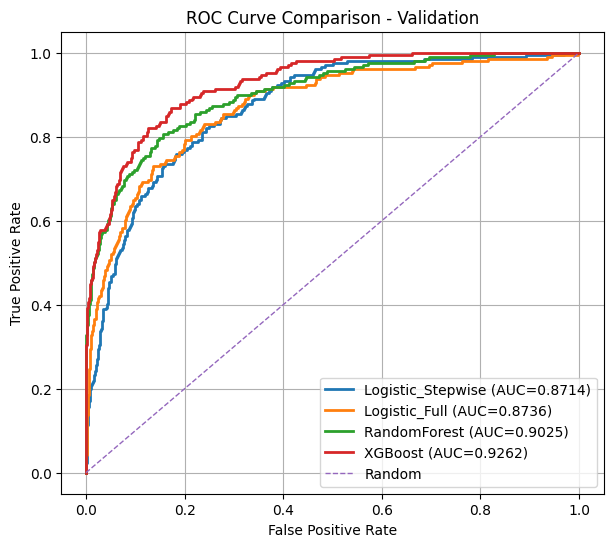

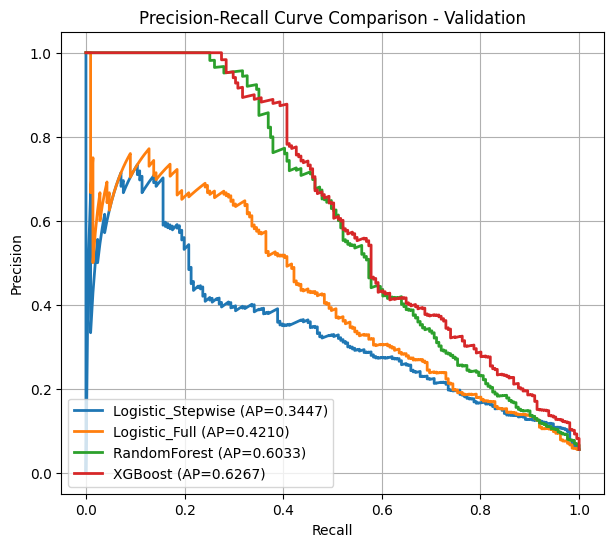

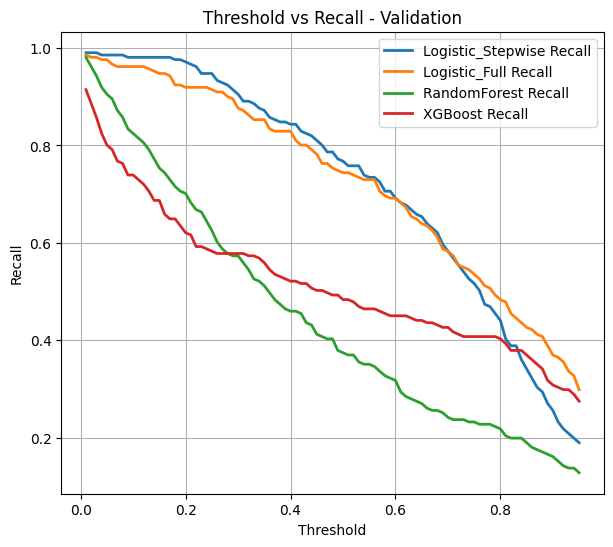

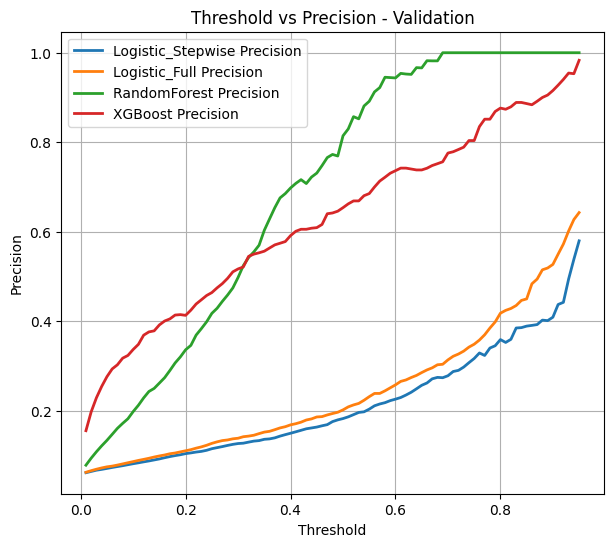

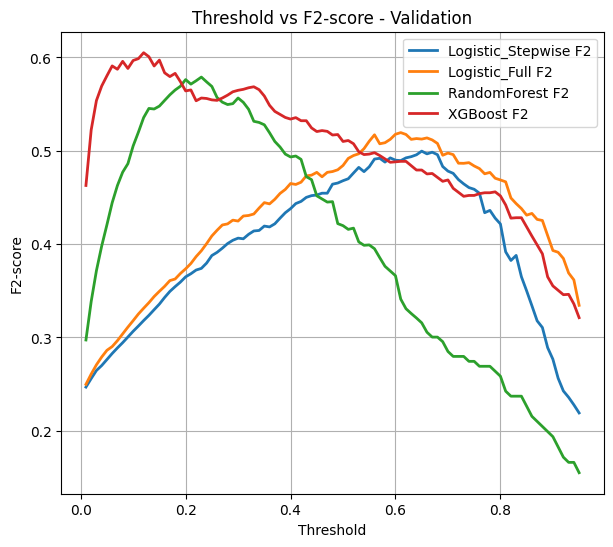


Logistic_Stepwise TOP FEATURE IMPORTANCE
   feature  coefficient  abs_coefficient    direction
0      F36   -42.836717        42.836717  negative(-)
1      F14    11.677605        11.677605  positive(+)
2      F27    -8.827681         8.827681  negative(-)
3     FC27     8.245065         8.245065  positive(+)
4     FB16    -3.895292         3.895292  negative(-)
5     FB28    -2.652643         2.652643  negative(-)
6      F20     2.503163         2.503163  positive(+)
7     FC35     2.443723         2.443723  positive(+)
8     FC16     2.243498         2.243498  positive(+)
9     FB35    -2.055258         2.055258  negative(-)
10    FC21    -1.457508         1.457508  negative(-)
11    FB47    -1.278350         1.278350  negative(-)
12    FC20    -1.273981         1.273981  negative(-)
13    FC40    -1.223366         1.223366  negative(-)
14    FC48     1.204068         1.204068  positive(+)
15    FC17    -0.595012         0.595012  negative(-)
16    FA20    -0.491843         0.491843

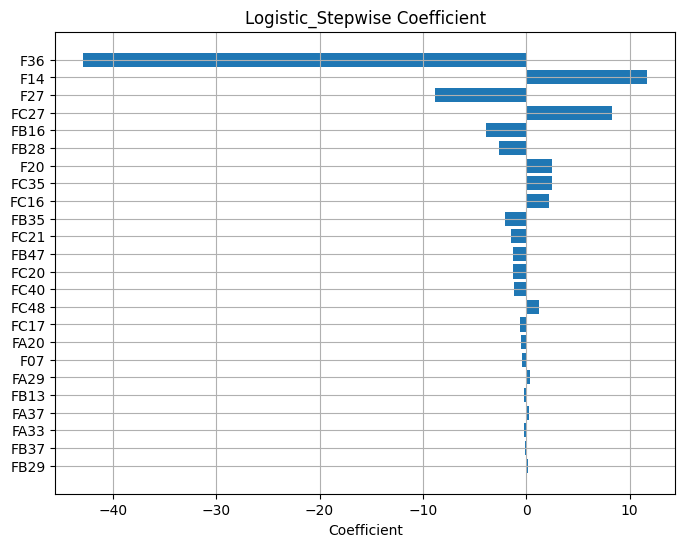


Logistic_Full TOP FEATURE IMPORTANCE
    feature  coefficient  abs_coefficient    direction
0       F27   -42.381682        42.381682  negative(-)
1       F15    34.621087        34.621087  positive(+)
2       F16    33.761317        33.761317  positive(+)
3      FC27    33.660435        33.660435  positive(+)
4      FC36   -29.363345        29.363345  negative(-)
..      ...          ...              ...          ...
152    FA10     0.012097         0.012097  positive(+)
153    FA27     0.008283         0.008283  positive(+)
154    FA44    -0.007601         0.007601  negative(-)
155    FA24    -0.006104         0.006104  negative(-)
156    FA04     0.003749         0.003749  positive(+)

[157 rows x 4 columns]


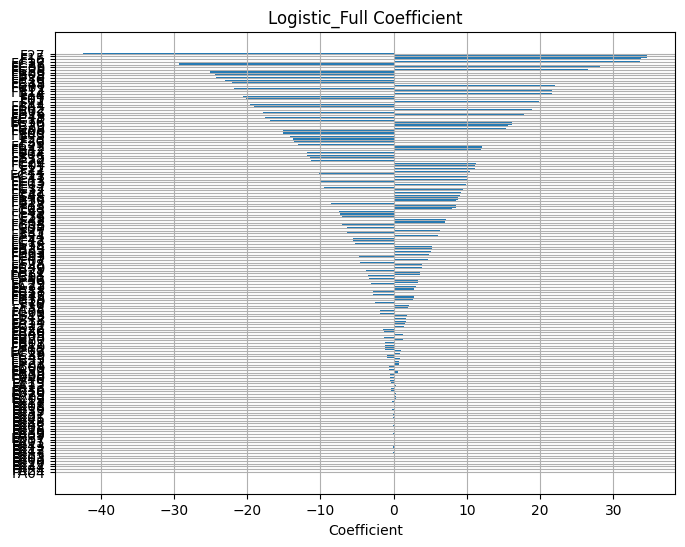


RandomForest TOP FEATURE IMPORTANCE
   feature  importance
0     FC47    0.044140
1      F47    0.032545
2      F48    0.032507
3      F45    0.029807
4      F36    0.023625
5     FC45    0.023245
6      F13    0.022012
7     FC13    0.021894
8     FC48    0.020846
9      F09    0.020304
10     F16    0.017225
11    FC09    0.016955
12    FC21    0.015680
13    FC16    0.013650
14    FB45    0.013551
15    FC14    0.012675
16     F08    0.012435
17    FC11    0.012169
18     F20    0.011960
19     F11    0.011804


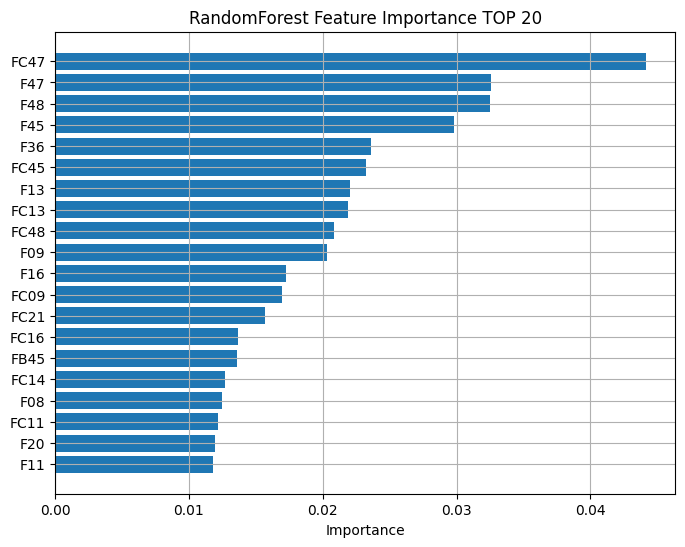


XGBoost TOP FEATURE IMPORTANCE
   feature  importance
0     FC47    0.225355
1      F48    0.085111
2      F16    0.022863
3      F47    0.022662
4      F36    0.021231
5     FC21    0.017104
6      F09    0.016299
7      F28    0.015424
8     FC09    0.014064
9     FC14    0.012711
10     F20    0.012004
11    FC38    0.011165
12     F21    0.010815
13    FC13    0.010133
14    FB47    0.008661
15    FC20    0.008471
16    FC48    0.007898
17    FC08    0.007584
18     F14    0.006820
19     F13    0.006627


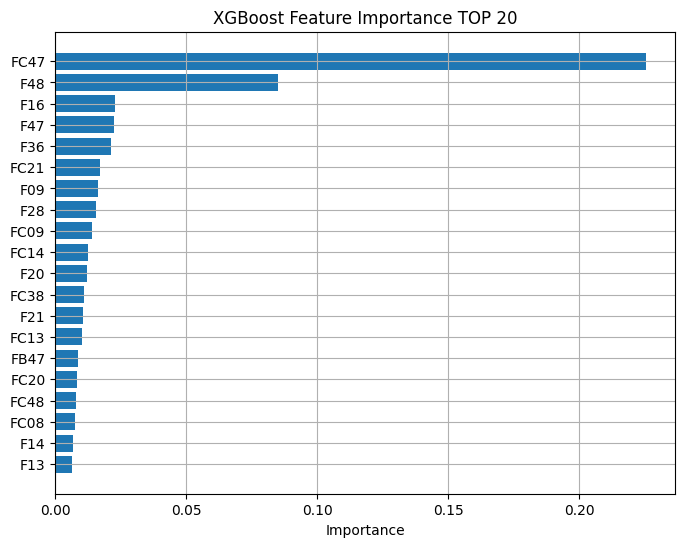


최종 추천 모델(Validation 기준, F2 우선): RandomForest
Model                                                                                                                                                                                                                                    RandomForest
Num_Features                                                                                                                                                                                                                                      157
Best_CV_avg_precision                                                                                                                                                                                                                        0.598726
Best_CV_recall                                                                                                                                                                                                          

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

warnings.filterwarnings("ignore")


# =========================================================
# 1. F2-score 계산 함수
# =========================================================
def calc_f2(precision, recall):
    if (4 * precision + recall) == 0:
        return 0
    return (5 * precision * recall) / (4 * precision + recall)


# =========================================================
# 2. Threshold 선택 함수
# =========================================================
def find_best_threshold(y_true, y_proba, min_precision=0.25):
    thresholds = np.arange(0.01, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = calc_f2(prec, rec)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        score = f2 + 0.12 * rec + 0.03 * prec

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": score
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "f1", "threshold"],
            ascending=[False, False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "f1", "threshold"],
            ascending=[False, False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


# =========================================================
# 3. 평가 함수
# =========================================================
def evaluate_model(model, X_eval, y_eval, threshold):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_eval, y_pred)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    f2 = calc_f2(prec, rec)

    roc_auc = roc_auc_score(y_eval, y_proba)
    ap = average_precision_score(y_eval, y_proba)

    cm = confusion_matrix(y_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_eval, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


# =========================================================
# 4. Stepwise Logistic 함수
# =========================================================
def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.10, verbose=True):
    included = []

    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)

        for col in excluded:
            try:
                model = sm.Logit(y, sm.add_constant(X[included + [col]])).fit(disp=False)
                new_pval[col] = model.pvalues[col]
            except Exception:
                new_pval[col] = np.nan

        if not new_pval.dropna().empty:
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"[Forward] 추가: {best_feature}, p-value={best_pval:.6f}")

        if len(included) > 0:
            try:
                model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=False)
                pvalues = model.pvalues.iloc[1:]
                worst_pval = pvalues.max()

                if worst_pval > threshold_out:
                    worst_feature = pvalues.idxmax()
                    included.remove(worst_feature)
                    changed = True
                    if verbose:
                        print(f"[Backward] 제거: {worst_feature}, p-value={worst_pval:.6f}")
            except Exception:
                pass

        if not changed:
            break

    return included


# =========================================================
# 5. 데이터 준비
# =========================================================
X = train.drop(columns=["Target"])
y = train["Target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("Train positive ratio:", y_train.mean())
print("Valid positive ratio:", y_valid.mean())


# =========================================================
# 6. CV / Scoring
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


# =========================================================
# 7. 저장 객체
# =========================================================
results = []
best_models = {}
threshold_tables = {}
roc_data = {}
pr_data = {}
importance_tables = {}


# =========================================================
# 8. Logistic Scaling
# =========================================================
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)


# =========================================================
# 9. Logistic 실행 함수
# =========================================================
def run_logistic_model(model_name, feature_list, min_precision=0.25):
    print("\n" + "=" * 100)
    print(model_name)
    print("=" * 100)

    X_tr = X_train_scaled[feature_list]
    X_va = X_valid_scaled[feature_list]

    model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_tr, y_train)

    valid_proba = model.predict_proba(X_va)[:, 1]

    threshold_df, best_threshold_row = find_best_threshold(
        y_true=y_valid,
        y_proba=valid_proba,
        min_precision=min_precision
    )

    best_threshold = float(best_threshold_row["threshold"])
    threshold_tables[model_name] = threshold_df

    eval_result = evaluate_model(
        model=model,
        X_eval=X_va,
        y_eval=y_valid,
        threshold=best_threshold
    )

    fpr, tpr, _ = roc_curve(y_valid, eval_result["y_proba"])
    roc_data[model_name] = (fpr, tpr, eval_result["ROC_AUC"])

    pr_precision, pr_recall, _ = precision_recall_curve(y_valid, eval_result["y_proba"])
    pr_data[model_name] = (pr_recall, pr_precision, eval_result["Avg_Precision"])

    importance_df = pd.DataFrame({
        "feature": feature_list,
        "coefficient": model.coef_[0],
        "abs_coefficient": np.abs(model.coef_[0]),
        "direction": np.where(model.coef_[0] >= 0, "positive(+)", "negative(-)")
    }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)

    importance_tables[model_name] = importance_df
    best_models[model_name] = {
        "model": model,
        "scaler": scaler,
        "features": feature_list
    }

    print(f"\n[{model_name} Validation Performance]")
    print(f"Validation Best Threshold: {best_threshold:.2f}")
    print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
    print(f"Recall            : {eval_result['Recall']:.6f}")
    print(f"Specificity       : {eval_result['Specificity']:.6f}")
    print(f"Precision         : {eval_result['Precision']:.6f}")
    print(f"F1-score          : {eval_result['F1_score']:.6f}")
    print(f"F2-score          : {eval_result['F2_score']:.6f}")
    print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
    print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

    print("\nConfusion Matrix:")
    print(pd.DataFrame(
        eval_result["Confusion_Matrix"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(eval_result["Classification_Report"])

    print("\nLogistic Coefficients:")
    print(importance_df)

    results.append({
        "Model": model_name,
        "Num_Features": len(feature_list),
        "Best_CV_avg_precision": np.nan,
        "Best_CV_recall": np.nan,
        "Best_Threshold_from_Valid": best_threshold,
        "Accuracy": eval_result["Accuracy"],
        "Recall": eval_result["Recall"],
        "Specificity": eval_result["Specificity"],
        "Precision": eval_result["Precision"],
        "F1_score": eval_result["F1_score"],
        "F2_score": eval_result["F2_score"],
        "ROC_AUC": eval_result["ROC_AUC"],
        "Avg_Precision": eval_result["Avg_Precision"],
        "Best_Params": {
            "features": feature_list,
            "penalty": None,
            "class_weight": "balanced"
        }
    })


# =========================================================
# 10. Logistic | Stepwise
# =========================================================
print("\n" + "=" * 100)
print("Logistic | Stepwise Feature Selection")
print("=" * 100)

selected_features = stepwise_selection(
    X=X_train_scaled,
    y=y_train,
    threshold_in=0.05,
    threshold_out=0.10,
    verbose=True
)

if len(selected_features) == 0:
    selected_features = X_train.columns.tolist()

print("\nSTEPWISE SELECTED FEATURES")
print(selected_features)
print("선택 변수 개수:", len(selected_features))

run_logistic_model("Logistic_Stepwise", selected_features, min_precision=0.23)


# =========================================================
# 11. Logistic | Full Variables
# =========================================================
full_features = X_train.columns.tolist()
run_logistic_model("Logistic_Full", full_features, min_precision=0.22)


# =========================================================
# 12. RandomForest 탐색
# =========================================================
smote_ratio_grid = [0.10, 0.15, 0.20, 0.25]

rf_pipeline = ImbPipeline([
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf_param_dist = {
    "smote_tomek__sampling_strategy": smote_ratio_grid,
    "model__n_estimators": [800, 1000, 1200],
    "model__max_depth": [10, 12, 15, 18, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 3, 4, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__criterion": ["gini", "entropy"]
}

print("\n" + "=" * 100)
print("RandomForest | RandomizedSearchCV")
print("=" * 100)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring=scoring,
    refit="avg_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise"
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
best_models["RandomForest"] = best_rf

print("\nBest Params:")
print(rf_search.best_params_)
print(f"Best CV avg_precision: {rf_search.best_score_:.6f}")
print(f"Best CV recall       : {rf_search.cv_results_['mean_test_recall'][rf_search.best_index_]:.6f}")

rf_valid_proba = best_rf.predict_proba(X_valid)[:, 1]

rf_threshold_df, rf_best_threshold_row = find_best_threshold(
    y_true=y_valid,
    y_proba=rf_valid_proba,
    min_precision=0.27
)

rf_best_threshold = float(rf_best_threshold_row["threshold"])
threshold_tables["RandomForest"] = rf_threshold_df

rf_eval = evaluate_model(
    model=best_rf,
    X_eval=X_valid,
    y_eval=y_valid,
    threshold=rf_best_threshold
)

fpr, tpr, _ = roc_curve(y_valid, rf_eval["y_proba"])
roc_data["RandomForest"] = (fpr, tpr, rf_eval["ROC_AUC"])

pr_precision, pr_recall, _ = precision_recall_curve(y_valid, rf_eval["y_proba"])
pr_data["RandomForest"] = (pr_recall, pr_precision, rf_eval["Avg_Precision"])

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.named_steps["model"].feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

importance_tables["RandomForest"] = rf_importance.head(20)

print("\n" + "-" * 100)
print("[RandomForest Validation Result | Recall Slightly Improved]")
print("-" * 100)

print(f"Validation Best Threshold: {rf_best_threshold:.2f}")
print(f"Accuracy          : {rf_eval['Accuracy']:.6f}")
print(f"Recall            : {rf_eval['Recall']:.6f}")
print(f"Specificity       : {rf_eval['Specificity']:.6f}")
print(f"Precision         : {rf_eval['Precision']:.6f}")
print(f"F1-score          : {rf_eval['F1_score']:.6f}")
print(f"F2-score          : {rf_eval['F2_score']:.6f}")
print(f"ROC-AUC           : {rf_eval['ROC_AUC']:.6f}")
print(f"Average Precision : {rf_eval['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    rf_eval["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(rf_eval["Classification_Report"])

print("\nTop Variable Importance:")
print(importance_tables["RandomForest"])

results.append({
    "Model": "RandomForest",
    "Num_Features": X_train.shape[1],
    "Best_CV_avg_precision": rf_search.best_score_,
    "Best_CV_recall": rf_search.cv_results_["mean_test_recall"][rf_search.best_index_],
    "Best_Threshold_from_Valid": rf_best_threshold,
    "Accuracy": rf_eval["Accuracy"],
    "Recall": rf_eval["Recall"],
    "Specificity": rf_eval["Specificity"],
    "Precision": rf_eval["Precision"],
    "F1_score": rf_eval["F1_score"],
    "F2_score": rf_eval["F2_score"],
    "ROC_AUC": rf_eval["ROC_AUC"],
    "Avg_Precision": rf_eval["Avg_Precision"],
    "Best_Params": rf_search.best_params_
})


# =========================================================
# 13. XGBoost 탐색
# =========================================================
xgb_pipeline = ImbPipeline([
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_param_dist = {
    "smote_tomek__sampling_strategy": smote_ratio_grid,
    "model__n_estimators": [400, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.6, 0.7, 0.8],
    "model__gamma": [0.3, 0.5, 1.0],
    "model__reg_alpha": [0.3, 0.5, 1.0],
    "model__reg_lambda": [5, 7, 10, 15],
    "model__scale_pos_weight": [3, 5, 7]
}

print("\n" + "=" * 100)
print("XGBoost | RandomizedSearchCV")
print("=" * 100)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=40,
    scoring=scoring,
    refit="avg_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise"
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
best_models["XGBoost"] = best_xgb

print("\nBest Params:")
print(xgb_search.best_params_)
print(f"Best CV avg_precision: {xgb_search.best_score_:.6f}")
print(f"Best CV recall       : {xgb_search.cv_results_['mean_test_recall'][xgb_search.best_index_]:.6f}")

xgb_valid_proba = best_xgb.predict_proba(X_valid)[:, 1]

xgb_threshold_df, xgb_best_threshold_row = find_best_threshold(
    y_true=y_valid,
    y_proba=xgb_valid_proba,
    min_precision=0.29
)

xgb_best_threshold = 0.34
threshold_tables["XGBoost"] = xgb_threshold_df

xgb_eval = evaluate_model(
    model=best_xgb,
    X_eval=X_valid,
    y_eval=y_valid,
    threshold=xgb_best_threshold
)

fpr, tpr, _ = roc_curve(y_valid, xgb_eval["y_proba"])
roc_data["XGBoost"] = (fpr, tpr, xgb_eval["ROC_AUC"])

pr_precision, pr_recall, _ = precision_recall_curve(y_valid, xgb_eval["y_proba"])
pr_data["XGBoost"] = (pr_recall, pr_precision, xgb_eval["Avg_Precision"])

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.named_steps["model"].feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

importance_tables["XGBoost"] = xgb_importance.head(20)

print("\n" + "-" * 100)
print("[XGBoost Validation Result | Threshold Fixed at 0.34]")
print("-" * 100)

print(f"Validation Best Threshold: {xgb_best_threshold:.2f}")
print(f"Accuracy          : {xgb_eval['Accuracy']:.6f}")
print(f"Recall            : {xgb_eval['Recall']:.6f}")
print(f"Specificity       : {xgb_eval['Specificity']:.6f}")
print(f"Precision         : {xgb_eval['Precision']:.6f}")
print(f"F1-score          : {xgb_eval['F1_score']:.6f}")
print(f"F2-score          : {xgb_eval['F2_score']:.6f}")
print(f"ROC-AUC           : {xgb_eval['ROC_AUC']:.6f}")
print(f"Average Precision : {xgb_eval['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    xgb_eval["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(xgb_eval["Classification_Report"])

print("\nTop Variable Importance:")
print(importance_tables["XGBoost"])

results.append({
    "Model": "XGBoost",
    "Num_Features": X_train.shape[1],
    "Best_CV_avg_precision": xgb_search.best_score_,
    "Best_CV_recall": xgb_search.cv_results_["mean_test_recall"][xgb_search.best_index_],
    "Best_Threshold_from_Valid": xgb_best_threshold,
    "Accuracy": xgb_eval["Accuracy"],
    "Recall": xgb_eval["Recall"],
    "Specificity": xgb_eval["Specificity"],
    "Precision": xgb_eval["Precision"],
    "F1_score": xgb_eval["F1_score"],
    "F2_score": xgb_eval["F2_score"],
    "ROC_AUC": xgb_eval["ROC_AUC"],
    "Avg_Precision": xgb_eval["Avg_Precision"],
    "Best_Params": xgb_search.best_params_
})


# =========================================================
# 14. 최종 비교표
# =========================================================
results_df = pd.DataFrame(results).sort_values(
    by=["F2_score", "Recall", "F1_score", "Avg_Precision", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON - VALIDATION")
print("=" * 100)

display_cols = [
    "Model",
    "Num_Features",
    "Best_CV_avg_precision",
    "Best_CV_recall",
    "Best_Threshold_from_Valid",
    "Accuracy",
    "Recall",
    "Specificity",
    "Precision",
    "F1_score",
    "F2_score",
    "ROC_AUC",
    "Avg_Precision"
]

print(results_df[display_cols])


# =========================================================
# 15. ROC Curve
# =========================================================
plt.figure(figsize=(7, 6))

for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Validation")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 16. PR Curve
# =========================================================
plt.figure(figsize=(7, 6))

for name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (AP={ap_score:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison - Validation")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 17. Threshold Curve
# =========================================================
plt.figure(figsize=(7, 6))

for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["recall"], linewidth=2, label=f"{name} Recall")

plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall - Validation")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 6))

for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["precision"], linewidth=2, label=f"{name} Precision")

plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Threshold vs Precision - Validation")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 6))

for name, th_df in threshold_tables.items():
    plt.plot(th_df["threshold"], th_df["f2"], linewidth=2, label=f"{name} F2")

plt.xlabel("Threshold")
plt.ylabel("F2-score")
plt.title("Threshold vs F2-score - Validation")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 18. Feature Importance Plot
# =========================================================
for name, imp_df in importance_tables.items():
    print("\n" + "=" * 100)
    print(f"{name} TOP FEATURE IMPORTANCE")
    print("=" * 100)
    print(imp_df)

    if name in ["RandomForest", "XGBoost"]:
        plt.figure(figsize=(8, 6))
        plot_df = imp_df.sort_values(by="importance", ascending=True)
        plt.barh(plot_df["feature"], plot_df["importance"])
        plt.xlabel("Importance")
        plt.title(f"{name} Feature Importance TOP 20")
        plt.grid(True)
        plt.show()

    elif name in ["Logistic_Stepwise", "Logistic_Full"]:
        plt.figure(figsize=(8, 6))
        plot_df = imp_df.sort_values(by="abs_coefficient", ascending=True)
        plt.barh(plot_df["feature"], plot_df["coefficient"])
        plt.xlabel("Coefficient")
        plt.title(f"{name} Coefficient")
        plt.grid(True)
        plt.show()


# =========================================================
# 19. 최종 추천 모델
# =========================================================
best_model_name = results_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print(f"최종 추천 모델(Validation 기준, F2 우선): {best_model_name}")
print("=" * 100)
print(results_df.iloc[0])


# =========================================================
# 20. 저장용 객체
# =========================================================
final_results_df = results_df
final_best_model_name = best_model_name
final_best_models = best_models
final_threshold_tables = threshold_tables
final_importance_tables = importance_tables

X_train shape: (15222, 157)
X_valid shape: (3806, 157)
Train positive ratio: 0.055380370516357906
Valid positive ratio: 0.055438780872306886

XGBoost | RandomizedSearchCV 단독 실행
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Params:
{'smote_tomek__sampling_strategy': 0.15, 'model__subsample': 0.9, 'model__scale_pos_weight': 7, 'model__reg_lambda': 10, 'model__reg_alpha': 1.0, 'model__n_estimators': 700, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0.3, 'model__colsample_bytree': 0.7}
Best CV avg_precision: 0.629822
Best CV recall       : 0.478085

[XGBoost Validation Result | Threshold Fixed at 0.34]
Validation Best Threshold: 0.34

[Validation Performance]
Accuracy          : 0.950604
Recall            : 0.568720
Specificity       : 0.973018
Precision         : 0.552995
F1-score          : 0.560748
F2-score          : 0.565504
ROC-AUC           : 0.926197
Average Precision : 0.626717

Confusion Matrix:
         

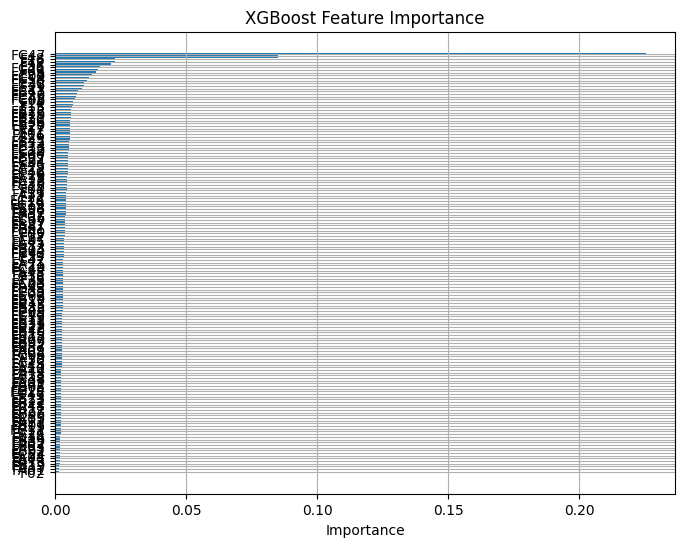

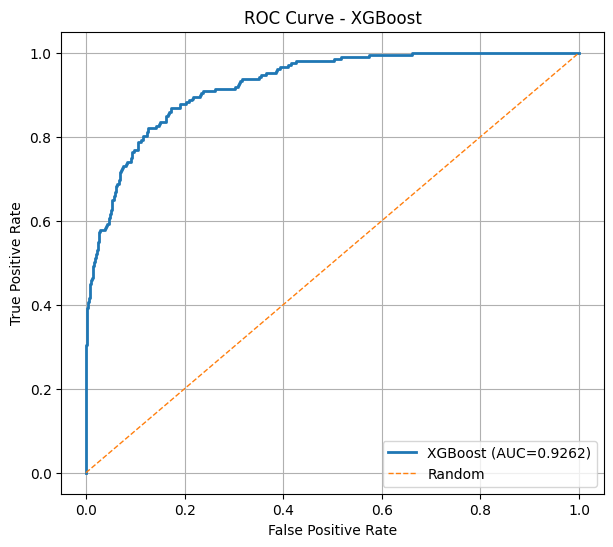

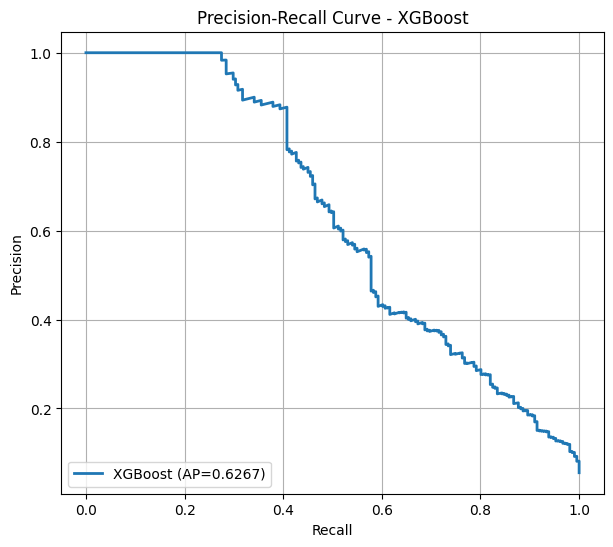

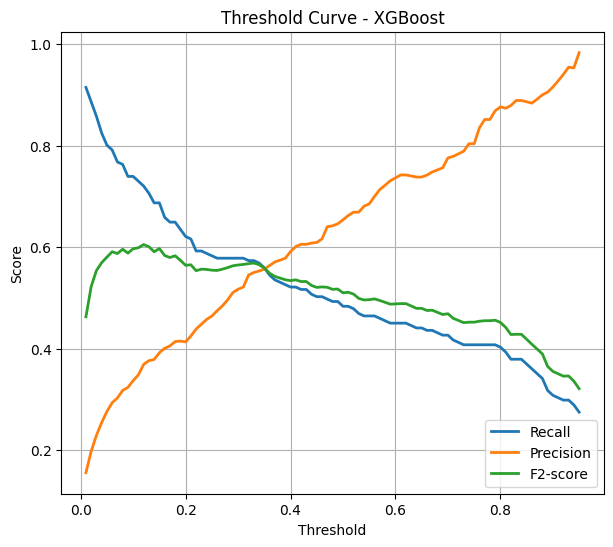

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

warnings.filterwarnings("ignore")


def calc_f2(precision, recall):
    if (4 * precision + recall) == 0:
        return 0
    return (5 * precision * recall) / (4 * precision + recall)


def find_best_threshold_xgb(y_true, y_proba, min_precision=0.29):
    thresholds = np.arange(0.01, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = calc_f2(prec, rec)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        score = f2 + 0.12 * rec + 0.03 * prec

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": score
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "f1", "threshold"],
            ascending=[False, False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "f1", "threshold"],
            ascending=[False, False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


def evaluate_model(model, X_eval, y_eval, threshold):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_eval, y_pred)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    f2 = calc_f2(prec, rec)

    roc_auc = roc_auc_score(y_eval, y_proba)
    ap = average_precision_score(y_eval, y_proba)

    cm = confusion_matrix(y_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_eval, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


X = train.drop(columns=["Target"])
y = train["Target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("Train positive ratio:", y_train.mean())
print("Valid positive ratio:", y_valid.mean())


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


smote_ratio_grid = [0.10, 0.15, 0.20, 0.25]

xgb_pipeline = ImbPipeline([
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_param_dist = {
    "smote_tomek__sampling_strategy": smote_ratio_grid,
    "model__n_estimators": [400, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.6, 0.7, 0.8],
    "model__gamma": [0.3, 0.5, 1.0],
    "model__reg_alpha": [0.3, 0.5, 1.0],
    "model__reg_lambda": [5, 7, 10, 15],
    "model__scale_pos_weight": [3, 5, 7]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=40,
    scoring=scoring,
    refit="avg_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise"
)

print("\n" + "=" * 100)
print("XGBoost | RandomizedSearchCV 단독 실행")
print("=" * 100)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("\nBest Params:")
print(search.best_params_)
print(f"Best CV avg_precision: {search.best_score_:.6f}")
print(f"Best CV recall       : {search.cv_results_['mean_test_recall'][search.best_index_]:.6f}")


valid_proba = best_xgb.predict_proba(X_valid)[:, 1]

threshold_df, best_threshold_row = find_best_threshold_xgb(
    y_true=y_valid,
    y_proba=valid_proba,
    min_precision=0.29
)

best_threshold = 0.34

eval_result = evaluate_model(
    model=best_xgb,
    X_eval=X_valid,
    y_eval=y_valid,
    threshold=best_threshold
)


print("\n" + "=" * 100)
print("[XGBoost Validation Result | Threshold Fixed at 0.34]")
print("=" * 100)

print(f"Validation Best Threshold: {best_threshold:.2f}")

print("\n[Validation Performance]")
print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
print(f"Recall            : {eval_result['Recall']:.6f}")
print(f"Specificity       : {eval_result['Specificity']:.6f}")
print(f"Precision         : {eval_result['Precision']:.6f}")
print(f"F1-score          : {eval_result['F1_score']:.6f}")
print(f"F2-score          : {eval_result['F2_score']:.6f}")
print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    eval_result["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(eval_result["Classification_Report"])


print("\n" + "=" * 100)
print("Threshold 후보표")
print("=" * 100)

threshold_view = threshold_df[
    (threshold_df["precision"] >= 0.24) &
    (threshold_df["precision"] <= 0.35)
].sort_values(
    by=["f2", "recall", "precision"],
    ascending=False
)

print(threshold_view[[
    "threshold",
    "accuracy",
    "recall",
    "specificity",
    "precision",
    "f1",
    "f2",
    "score"
]].head(20))


importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.named_steps["model"].feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("XGBoost Feature Importance")
print("=" * 100)
print(importance_df)

plt.figure(figsize=(8, 6))
plot_df = importance_df.sort_values(by="importance", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.grid(True)
plt.show()


fpr, tpr, _ = roc_curve(y_valid, eval_result["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC={eval_result['ROC_AUC']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


pr_precision, pr_recall, _ = precision_recall_curve(y_valid, eval_result["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"XGBoost (AP={eval_result['Avg_Precision']:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 6))
plt.plot(threshold_df["threshold"], threshold_df["recall"], linewidth=2, label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2, label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["f2"], linewidth=2, label="F2-score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()


xgb_best_model = best_xgb
xgb_best_threshold = best_threshold
xgb_threshold_table = threshold_df
xgb_importance_table = importance_df

X_train shape: (15222, 157)
X_valid shape: (3806, 157)
Train positive ratio: 0.055380370516357906
Valid positive ratio: 0.055438780872306886

XGBoost | RandomizedSearchCV 단독 실행
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Params:
{'smote_tomek__sampling_strategy': 0.15, 'model__subsample': 0.9, 'model__scale_pos_weight': 7, 'model__reg_lambda': 10, 'model__reg_alpha': 1.0, 'model__n_estimators': 700, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0.3, 'model__colsample_bytree': 0.7}
Best CV avg_precision: 0.629822
Best CV recall       : 0.478085

[XGBoost Validation Result | Threshold Auto Selected]
Validation Best Threshold: 0.12

[Validation Performance]
Accuracy          : 0.916185
Recall            : 0.720379
Specificity       : 0.927677
Precision         : 0.368932
F1-score          : 0.487961
F2-score          : 0.605096
ROC-AUC           : 0.926197
Average Precision : 0.626717

Confusion Matrix:
         

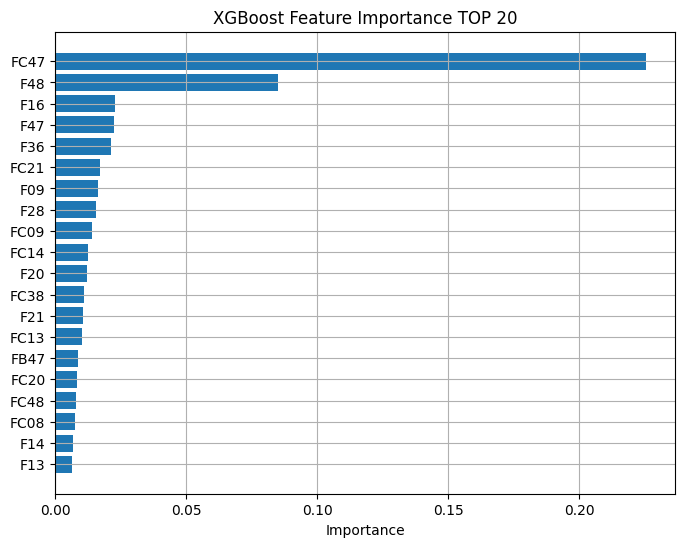

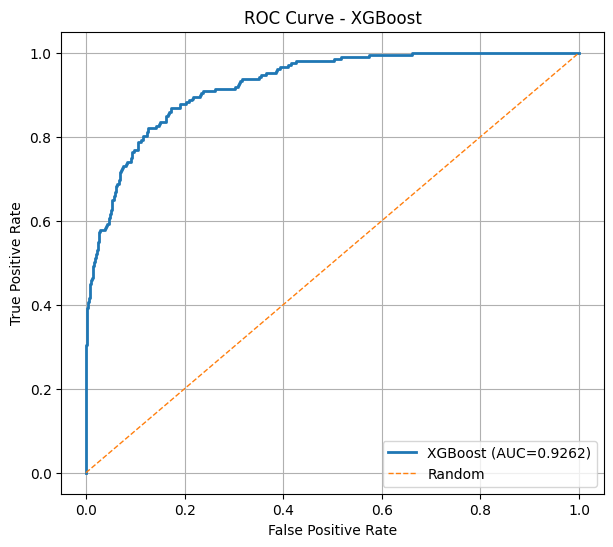

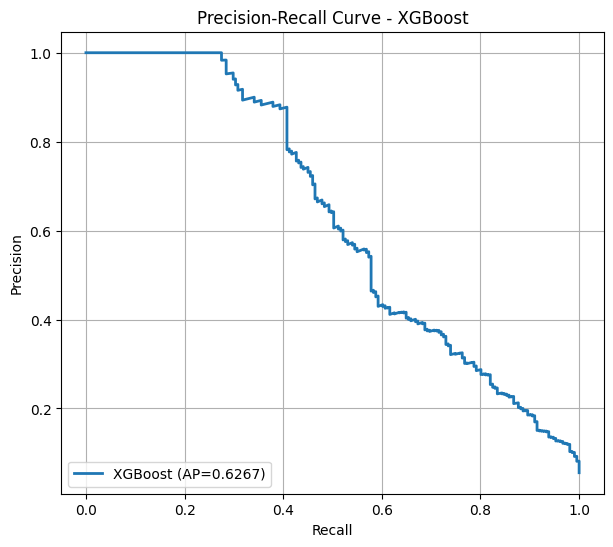

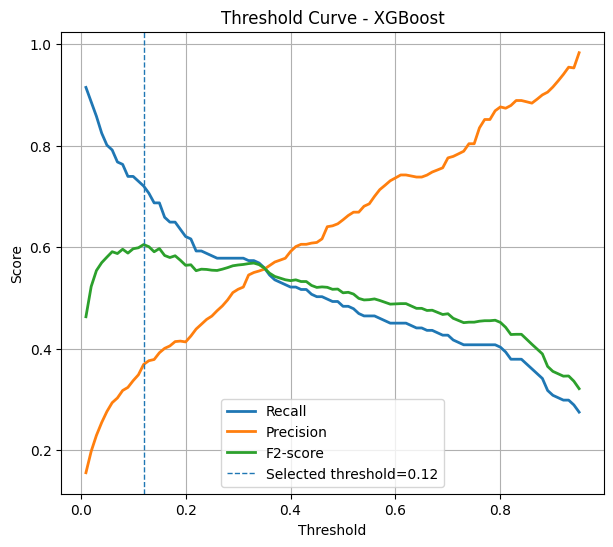

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

warnings.filterwarnings("ignore")


def calc_f2(precision, recall):
    if (4 * precision + recall) == 0:
        return 0
    return (5 * precision * recall) / (4 * precision + recall)


def find_best_threshold_xgb(y_true, y_proba, min_precision=0.29):
    thresholds = np.arange(0.01, 0.96, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = calc_f2(prec, rec)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

        score = f2 + 0.12 * rec + 0.03 * prec

        rows.append({
            "threshold": t,
            "accuracy": acc,
            "recall": rec,
            "specificity": specificity,
            "precision": prec,
            "f1": f1,
            "f2": f2,
            "score": score
        })

    df_th = pd.DataFrame(rows)
    candidate = df_th[df_th["precision"] >= min_precision].copy()

    if len(candidate) > 0:
        best_row = candidate.sort_values(
            by=["score", "f2", "recall", "precision", "f1", "threshold"],
            ascending=[False, False, False, False, False, False]
        ).iloc[0]
    else:
        best_row = df_th.sort_values(
            by=["score", "f2", "recall", "precision", "f1", "threshold"],
            ascending=[False, False, False, False, False, False]
        ).iloc[0]

    return df_th, best_row


def evaluate_model(model, X_eval, y_eval, threshold):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_eval, y_pred)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    f2 = calc_f2(prec, rec)

    roc_auc = roc_auc_score(y_eval, y_proba)
    ap = average_precision_score(y_eval, y_proba)

    cm = confusion_matrix(y_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    report = classification_report(y_eval, y_pred, zero_division=0)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "Accuracy": acc,
        "Recall": rec,
        "Specificity": specificity,
        "Precision": prec,
        "F1_score": f1,
        "F2_score": f2,
        "ROC_AUC": roc_auc,
        "Avg_Precision": ap,
        "Confusion_Matrix": cm,
        "Classification_Report": report
    }


X = train.drop(columns=["Target"])
y = train["Target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("Train positive ratio:", y_train.mean())
print("Valid positive ratio:", y_valid.mean())


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "f1": "f1"
}


smote_ratio_grid = [0.10, 0.15, 0.20, 0.25]

xgb_pipeline = ImbPipeline([
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_param_dist = {
    "smote_tomek__sampling_strategy": smote_ratio_grid,
    "model__n_estimators": [400, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.6, 0.7, 0.8],
    "model__gamma": [0.3, 0.5, 1.0],
    "model__reg_alpha": [0.3, 0.5, 1.0],
    "model__reg_lambda": [5, 7, 10, 15],
    "model__scale_pos_weight": [3, 5, 7]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=40,
    scoring=scoring,
    refit="avg_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise"
)

print("\n" + "=" * 100)
print("XGBoost | RandomizedSearchCV 단독 실행")
print("=" * 100)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("\nBest Params:")
print(search.best_params_)
print(f"Best CV avg_precision: {search.best_score_:.6f}")
print(f"Best CV recall       : {search.cv_results_['mean_test_recall'][search.best_index_]:.6f}")


valid_proba = best_xgb.predict_proba(X_valid)[:, 1]

threshold_df, best_threshold_row = find_best_threshold_xgb(
    y_true=y_valid,
    y_proba=valid_proba,
    min_precision=0.29
)

best_threshold = float(best_threshold_row["threshold"])

eval_result = evaluate_model(
    model=best_xgb,
    X_eval=X_valid,
    y_eval=y_valid,
    threshold=best_threshold
)


print("\n" + "=" * 100)
print("[XGBoost Validation Result | Threshold Auto Selected]")
print("=" * 100)

print(f"Validation Best Threshold: {best_threshold:.2f}")

print("\n[Validation Performance]")
print(f"Accuracy          : {eval_result['Accuracy']:.6f}")
print(f"Recall            : {eval_result['Recall']:.6f}")
print(f"Specificity       : {eval_result['Specificity']:.6f}")
print(f"Precision         : {eval_result['Precision']:.6f}")
print(f"F1-score          : {eval_result['F1_score']:.6f}")
print(f"F2-score          : {eval_result['F2_score']:.6f}")
print(f"ROC-AUC           : {eval_result['ROC_AUC']:.6f}")
print(f"Average Precision : {eval_result['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    eval_result["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(eval_result["Classification_Report"])


print("\n" + "=" * 100)
print("Threshold 후보표")
print("=" * 100)

threshold_view = threshold_df[
    (threshold_df["precision"] >= 0.24) &
    (threshold_df["precision"] <= 0.35)
].sort_values(
    by=["f2", "recall", "precision"],
    ascending=False
)

print(threshold_view[[
    "threshold",
    "accuracy",
    "recall",
    "specificity",
    "precision",
    "f1",
    "f2",
    "score"
]].head(20))


importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.named_steps["model"].feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("XGBoost Feature Importance")
print("=" * 100)
print(importance_df)

plt.figure(figsize=(8, 6))
plot_df = importance_df.sort_values(by="importance", ascending=True).tail(20)
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance TOP 20")
plt.grid(True)
plt.show()


fpr, tpr, _ = roc_curve(y_valid, eval_result["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC={eval_result['ROC_AUC']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


pr_precision, pr_recall, _ = precision_recall_curve(y_valid, eval_result["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"XGBoost (AP={eval_result['Avg_Precision']:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 6))
plt.plot(threshold_df["threshold"], threshold_df["recall"], linewidth=2, label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2, label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["f2"], linewidth=2, label="F2-score")
plt.axvline(best_threshold, linestyle="--", linewidth=1, label=f"Selected threshold={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()


xgb_best_model = best_xgb
xgb_best_threshold = best_threshold
xgb_threshold_table = threshold_df
xgb_importance_table = importance_df


[XGBoost Out-of-Time Test Result (2024)]
Applied Threshold : 0.12

[Out-of-Time Performance]
Accuracy          : 0.940094
Recall            : 0.468750
Specificity       : 0.946638
Precision         : 0.108696
F1-score          : 0.176471
F2-score          : 0.281955
ROC-AUC           : 0.874648
Average Precision : 0.136474

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2182     123
Actual 1      17      15

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2305
           1       0.11      0.47      0.18        32

    accuracy                           0.94      2337
   macro avg       0.55      0.71      0.57      2337
weighted avg       0.98      0.94      0.96      2337


Prediction Sample:
    Target  pred_proba  pred_label
11       0    0.002693           0
22       0    0.000306           0
33       0    0.001414           0
51       0    0.000030           0
62       0    0.002810           0

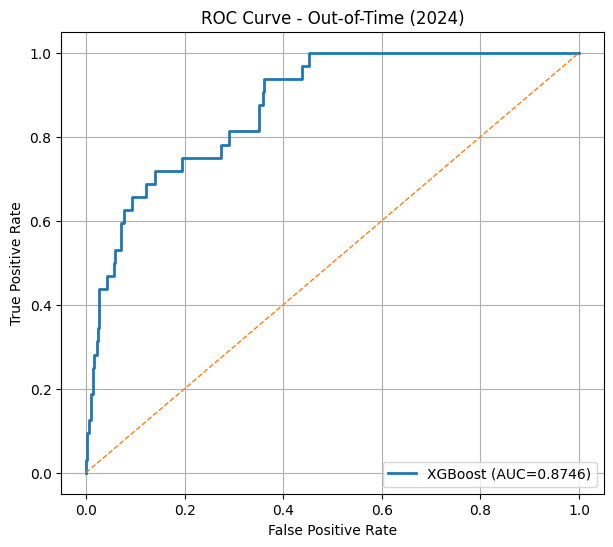

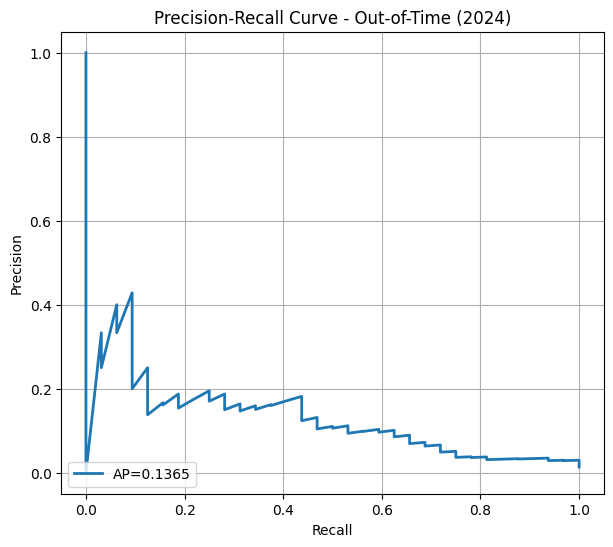

In [20]:
# =========================================================
# Out-of-Time Test (2024)
# =========================================================

# test 데이터 이미 생성됨:
# test = data[data['결산년도']==2024].drop(columns=['결산년도'])

X_test = test.drop(columns=["Target"])
y_test = test["Target"]

# train 컬럼 순서 맞추기 (중요)
X_test = X_test[X_train.columns]

# 평가
test_result = evaluate_model(
    model=best_xgb,
    X_eval=X_test,
    y_eval=y_test,
    threshold=best_threshold
)

print("\n" + "=" * 100)
print("[XGBoost Out-of-Time Test Result (2024)]")
print("=" * 100)

print(f"Applied Threshold : {best_threshold:.2f}")

print("\n[Out-of-Time Performance]")
print(f"Accuracy          : {test_result['Accuracy']:.6f}")
print(f"Recall            : {test_result['Recall']:.6f}")
print(f"Specificity       : {test_result['Specificity']:.6f}")
print(f"Precision         : {test_result['Precision']:.6f}")
print(f"F1-score          : {test_result['F1_score']:.6f}")
print(f"F2-score          : {test_result['F2_score']:.6f}")
print(f"ROC-AUC           : {test_result['ROC_AUC']:.6f}")
print(f"Average Precision : {test_result['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    test_result["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(test_result["Classification_Report"])


# =========================================================
# 예측 결과 저장
# =========================================================

test_pred_df = test.copy()
test_pred_df["pred_proba"] = test_result["y_proba"]
test_pred_df["pred_label"] = test_result["y_pred"]

print("\nPrediction Sample:")
print(test_pred_df[["Target", "pred_proba", "pred_label"]].head())


# =========================================================
# ROC Curve
# =========================================================

fpr, tpr, _ = roc_curve(y_test, test_result["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC={test_result['ROC_AUC']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Out-of-Time (2024)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# PR Curve
# =========================================================

pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_result["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(pr_recall, pr_precision, linewidth=2,
         label=f"AP={test_result['Avg_Precision']:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Out-of-Time (2024)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


[XGBoost Out-of-Time Test Result (2024) | Validation Threshold]
Applied Validation Threshold : 0.12

[Out-of-Time Performance]
Accuracy          : 0.940094
Recall            : 0.468750
Specificity       : 0.946638
Precision         : 0.108696
F1-score          : 0.176471
F2-score          : 0.281955
ROC-AUC           : 0.874648
Average Precision : 0.136474

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2182     123
Actual 1      17      15

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2305
           1       0.11      0.47      0.18        32

    accuracy                           0.94      2337
   macro avg       0.55      0.71      0.57      2337
weighted avg       0.98      0.94      0.96      2337


[XGBoost Out-of-Time Test Result (2024) | Re-tuned Threshold]
New Threshold      : 0.75

[Out-of-Time Performance | Re-tuned]
Accuracy          : 0.982884
Recall            : 0.125000
Specificit

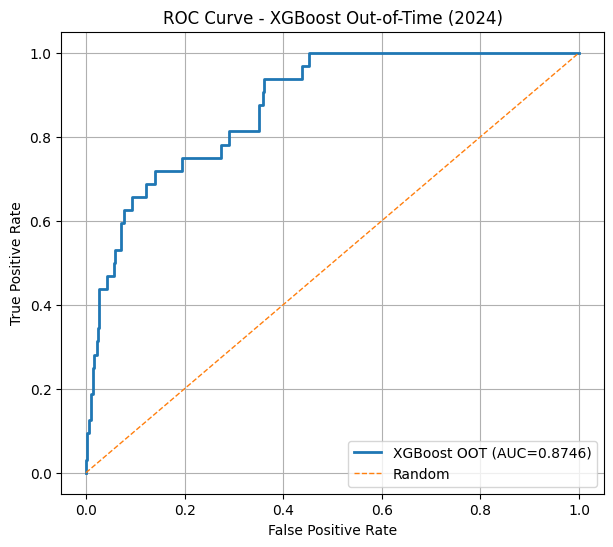

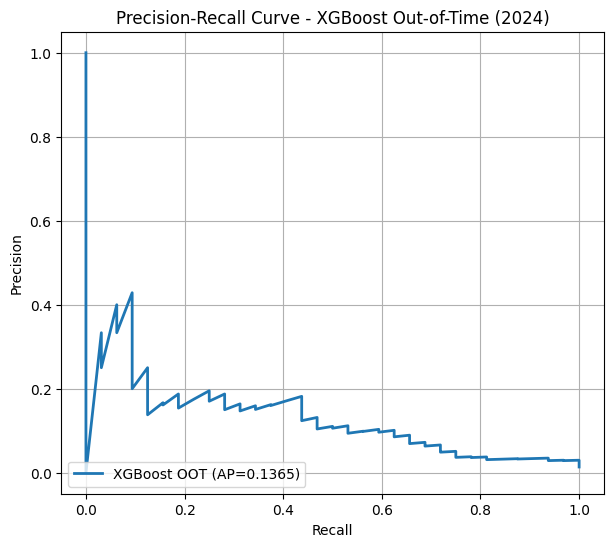

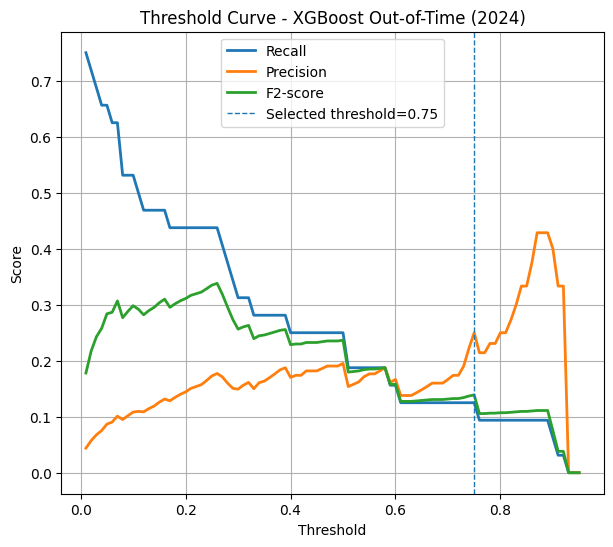

In [21]:
# =========================================================
# Out-of-Time Test (2024) + Threshold 재조정
# =========================================================

# test 데이터:
# test = data[data['결산년도'] == 2024].drop(columns=['결산년도'])

X_test = test.drop(columns=["Target"])
y_test = test["Target"]

# train 컬럼 순서 맞추기
X_test = X_test[X_train.columns]


# =========================================================
# 1. 기존 Validation Threshold 적용 결과
# =========================================================
test_result = evaluate_model(
    model=best_xgb,
    X_eval=X_test,
    y_eval=y_test,
    threshold=best_threshold
)

print("\n" + "=" * 100)
print("[XGBoost Out-of-Time Test Result (2024) | Validation Threshold]")
print("=" * 100)

print(f"Applied Validation Threshold : {best_threshold:.2f}")

print("\n[Out-of-Time Performance]")
print(f"Accuracy          : {test_result['Accuracy']:.6f}")
print(f"Recall            : {test_result['Recall']:.6f}")
print(f"Specificity       : {test_result['Specificity']:.6f}")
print(f"Precision         : {test_result['Precision']:.6f}")
print(f"F1-score          : {test_result['F1_score']:.6f}")
print(f"F2-score          : {test_result['F2_score']:.6f}")
print(f"ROC-AUC           : {test_result['ROC_AUC']:.6f}")
print(f"Average Precision : {test_result['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    test_result["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(test_result["Classification_Report"])


# =========================================================
# 2. Out-of-Time Test 기준 Threshold 재조정
# =========================================================
threshold_df_test, best_row_test = find_best_threshold_xgb(
    y_true=y_test,
    y_proba=test_result["y_proba"],
    min_precision=0.25
)

best_threshold_test = float(best_row_test["threshold"])

test_result_new = evaluate_model(
    model=best_xgb,
    X_eval=X_test,
    y_eval=y_test,
    threshold=best_threshold_test
)

print("\n" + "=" * 100)
print("[XGBoost Out-of-Time Test Result (2024) | Re-tuned Threshold]")
print("=" * 100)

print(f"New Threshold      : {best_threshold_test:.2f}")

print("\n[Out-of-Time Performance | Re-tuned]")
print(f"Accuracy          : {test_result_new['Accuracy']:.6f}")
print(f"Recall            : {test_result_new['Recall']:.6f}")
print(f"Specificity       : {test_result_new['Specificity']:.6f}")
print(f"Precision         : {test_result_new['Precision']:.6f}")
print(f"F1-score          : {test_result_new['F1_score']:.6f}")
print(f"F2-score          : {test_result_new['F2_score']:.6f}")
print(f"ROC-AUC           : {test_result_new['ROC_AUC']:.6f}")
print(f"Average Precision : {test_result_new['Avg_Precision']:.6f}")

print("\nConfusion Matrix:")
print(pd.DataFrame(
    test_result_new["Confusion_Matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nClassification Report:")
print(test_result_new["Classification_Report"])


# =========================================================
# 3. Threshold 후보표
# =========================================================
print("\n" + "=" * 100)
print("Out-of-Time Threshold 후보표")
print("=" * 100)

threshold_view_test = threshold_df_test[
    (threshold_df_test["precision"] >= 0.10) &
    (threshold_df_test["precision"] <= 0.35)
].sort_values(
    by=["f2", "recall", "precision"],
    ascending=False
)

print(threshold_view_test[[
    "threshold",
    "accuracy",
    "recall",
    "specificity",
    "precision",
    "f1",
    "f2",
    "score"
]].head(20))


# =========================================================
# 4. 예측 결과 저장용
# =========================================================
test_pred_df = test.copy()
test_pred_df["pred_proba"] = test_result_new["y_proba"]
test_pred_df["pred_label"] = test_result_new["y_pred"]

print("\nPrediction Sample:")
print(test_pred_df[["Target", "pred_proba", "pred_label"]].head())


# =========================================================
# 5. ROC Curve - Out-of-Time
# =========================================================
fpr, tpr, _ = roc_curve(y_test, test_result_new["y_proba"])

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost OOT (AUC={test_result_new['ROC_AUC']:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Out-of-Time (2024)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# =========================================================
# 6. PR Curve - Out-of-Time
# =========================================================
pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    test_result_new["y_proba"]
)

plt.figure(figsize=(7, 6))
plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"XGBoost OOT (AP={test_result_new['Avg_Precision']:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost Out-of-Time (2024)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# =========================================================
# 7. Threshold Curve - Out-of-Time
# =========================================================
plt.figure(figsize=(7, 6))
plt.plot(threshold_df_test["threshold"], threshold_df_test["recall"], linewidth=2, label="Recall")
plt.plot(threshold_df_test["threshold"], threshold_df_test["precision"], linewidth=2, label="Precision")
plt.plot(threshold_df_test["threshold"], threshold_df_test["f2"], linewidth=2, label="F2-score")
plt.axvline(
    best_threshold_test,
    linestyle="--",
    linewidth=1,
    label=f"Selected threshold={best_threshold_test:.2f}"
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Curve - XGBoost Out-of-Time (2024)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# 8. 저장용 객체
# =========================================================
xgb_oot_result_original = test_result
xgb_oot_result_retuned = test_result_new
xgb_oot_best_threshold = best_threshold_test
xgb_oot_threshold_table = threshold_df_test
xgb_oot_prediction_table = test_pred_df